# Sonar + Vision Combined MOT Analysis

Synchronises sonar (~15.6 fps) and vision (~15–22 fps) ground truth using nanosecond timestamps 
(image filename = frame_id). All plots use **time in seconds from the earliest frame** of each sequence.

| | Sonar | Vision |
|---|---|---|
| Perspective | top-down (ROV below, looking up) | side-on |
| Classes | fish (1), net (2) | fish (1) |
| Coords | physical metres available | pixel only |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
from pathlib import Path

try:
    from sklearn.cluster import DBSCAN
    HAS_SKLEARN = True
except ImportError:
    HAS_SKLEARN = False
    print("scikit-learn not found – clustering section will be skipped")

In [2]:
# ── Paths (relative to data-processing/) ─────────────────────────────────────
SONAR_ROOT  = Path("sonar/MOT")
VISION_ROOT = Path("vision/MOT")
SEQUENCES   = sorted([p.name for p in SONAR_ROOT.iterdir() if p.is_dir()])

GT_COLS = ["frame_id","track_id","x","y","w","h","not_ignored","class_id","visibility"]

# ── Sonar physical mapping (net_sonar_labelingview_config) ───────────────────
S_W, S_H   = 1200, 700
S_YMAX_M   = 20.0
S_XSPAN_M  = S_YMAX_M * np.sin(np.deg2rad(45.0))   # ≈

def sonar_px_to_m(cx, cy):
    """Pixel centre → (x_m, y_m, range_m). ROV at bottom: row 699 = 0 m.
    Step sizes from endpoint=False linspace: Δy = Y_MAX/H, Δx = 2*X_SPAN/W.
    """
    y_m = (S_H - 1 - cy) * (S_YMAX_M / S_H)
    x_m = cx * (2 * S_XSPAN_M / S_W) - S_XSPAN_M
    return x_m, y_m, np.sqrt(x_m**2 + y_m**2)

# ── Colour palette ────────────────────────────────────────────────────────────
C_SONAR  = "#1565C0"   # blue
C_VISION = "#2E7D32"   # green
C_NET    = "#C62828"   # red
C_BOTH   = "#6A1B9A"   # purple
C_NONE   = "#B0BEC5"   # grey
SEQ_COLS = ["#E65100","#1565C0","#2E7D32","#6A1B9A","#00838F"]  # one per sequence (5)

# ── Plot defaults ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 10,
})

In [3]:
def _load(seq, root, modality):
    seq_path = root / seq
    img_dir  = seq_path / "frames" if modality == "sonar" else seq_path / "frames" / seq
    imgs     = sorted(img_dir.glob("*.jpg"))
    ts       = np.array([int(f.stem) for f in imgs], dtype=np.int64)

    df = pd.read_csv(seq_path / "gt" / "gt.txt", header=None, names=GT_COLS)
    df["frame_id"]     = df["frame_id"].astype(np.int64)
    df["sequence"]     = seq
    df["modality"]     = modality
    df["total_frames"] = len(ts)
    df["frame_norm"]   = df["frame_id"].map({t: i+1 for i, t in enumerate(ts)})

    if modality == "sonar":
        cx, cy = df["x"] + df["w"]/2, df["y"] + df["h"]/2
        df["cx"], df["cy"] = cx, cy
        df["x_m"], df["y_m"], df["range_m"] = sonar_px_to_m(cx, cy)
        df["w_m"] = df["w"] * (2 * S_XSPAN_M / S_W)
        df["y_near_m"] = np.maximum(0, (S_H - 1 - (df["y"] + df["h"])) * (S_YMAX_M / S_H))
    return df, ts

def load_all():
    data = {}
    for seq in SEQUENCES:
        s_df, s_ts = _load(seq, SONAR_ROOT,  "sonar")
        v_df, v_ts = _load(seq, VISION_ROOT, "vision")

        t0 = min(s_ts[0], v_ts[0])   # nanosecond reference
        for df, ts in [(s_df, s_ts), (v_df, v_ts)]:
            df["time_s"] = (df["frame_id"] - t0) / 1e9

        # Full frame timelines (every frame, including empties)
        s_tl = pd.DataFrame({"frame_norm": range(1, len(s_ts)+1),
                              "time_s": (s_ts - t0) / 1e9})
        v_tl = pd.DataFrame({"frame_norm": range(1, len(v_ts)+1),
                              "time_s": (v_ts - t0) / 1e9})

        data[seq] = {
            "s": {"df": s_df, "ts": s_ts, "tl": s_tl},
            "v": {"df": v_df, "ts": v_ts, "tl": v_tl},
            "t0": t0,
            "dur": (max(s_ts[-1], v_ts[-1]) - t0) / 1e9,
        }
    return data

seqdata = load_all()


def frame_count(df, tl, class_id=1):
    """Fish/net count per frame (zero-filled using full timeline)."""
    fc = df[df["class_id"]==class_id].groupby("frame_norm").size().reset_index(name="n")
    out = tl.merge(fc, on="frame_norm", how="left")
    out["n"] = out["n"].fillna(0).astype(int)
    return out  # columns: frame_norm, time_s, n


def time_bin(series_time, series_val, bin_s=1.0, agg="mean"):
    """Bin a (time_s, value) series into fixed-width windows."""
    dur  = series_time.max()
    edges = np.arange(0, dur + bin_s, bin_s)
    cats  = pd.cut(series_time, bins=edges, labels=edges[:-1], include_lowest=True).astype(float)
    grp   = series_val.groupby(cats)
    fn    = grp.mean if agg == "mean" else grp.sum
    return fn().reset_index()

In [4]:
# ── Summary table ─────────────────────────────────────────────────────────────
rows = []
for seq, d in seqdata.items():
    s, v = d["s"], d["v"]
    rows.append({
        "Sequence":           seq[-8:],
        "Duration (s)":       round(d["dur"], 1),
        "Sonar frames":       len(s["ts"]),
        "Sonar FPS":          round(len(s["ts"]) / d["dur"], 1),
        "Sonar fish annots":  int((s["df"]["class_id"]==1).sum()),
        "Net annots":         int((s["df"]["class_id"]==2).sum()),
        "Vision frames":      len(v["ts"]),
        "Vision FPS":         round(len(v["ts"]) / d["dur"], 1),
        "Vision fish annots": int((v["df"]["class_id"]==1).sum()),
    })
display(pd.DataFrame(rows))


,Sequence,Duration (s),Sonar frames,Sonar FPS,Sonar fish annots,Net annots,Vision frames,Vision FPS,Vision fish annots
0,14-31-29,67.8,1060,15.6,946,1060,1500,22.1,4967
1,17-02-00,55.0,860,15.6,442,860,1212,22.0,1104
2,17-14-36,43.4,673,15.5,457,673,834,19.2,899
3,17-39-32,39.1,607,15.5,246,607,625,16.0,500
4,17-55-40,50.1,781,15.6,780,781,796,15.9,1667


## 1  Synchronised detection timeline
Sonar (blue) and vision (green) fish counts on a common time axis.  
Red shading = net detected by sonar.

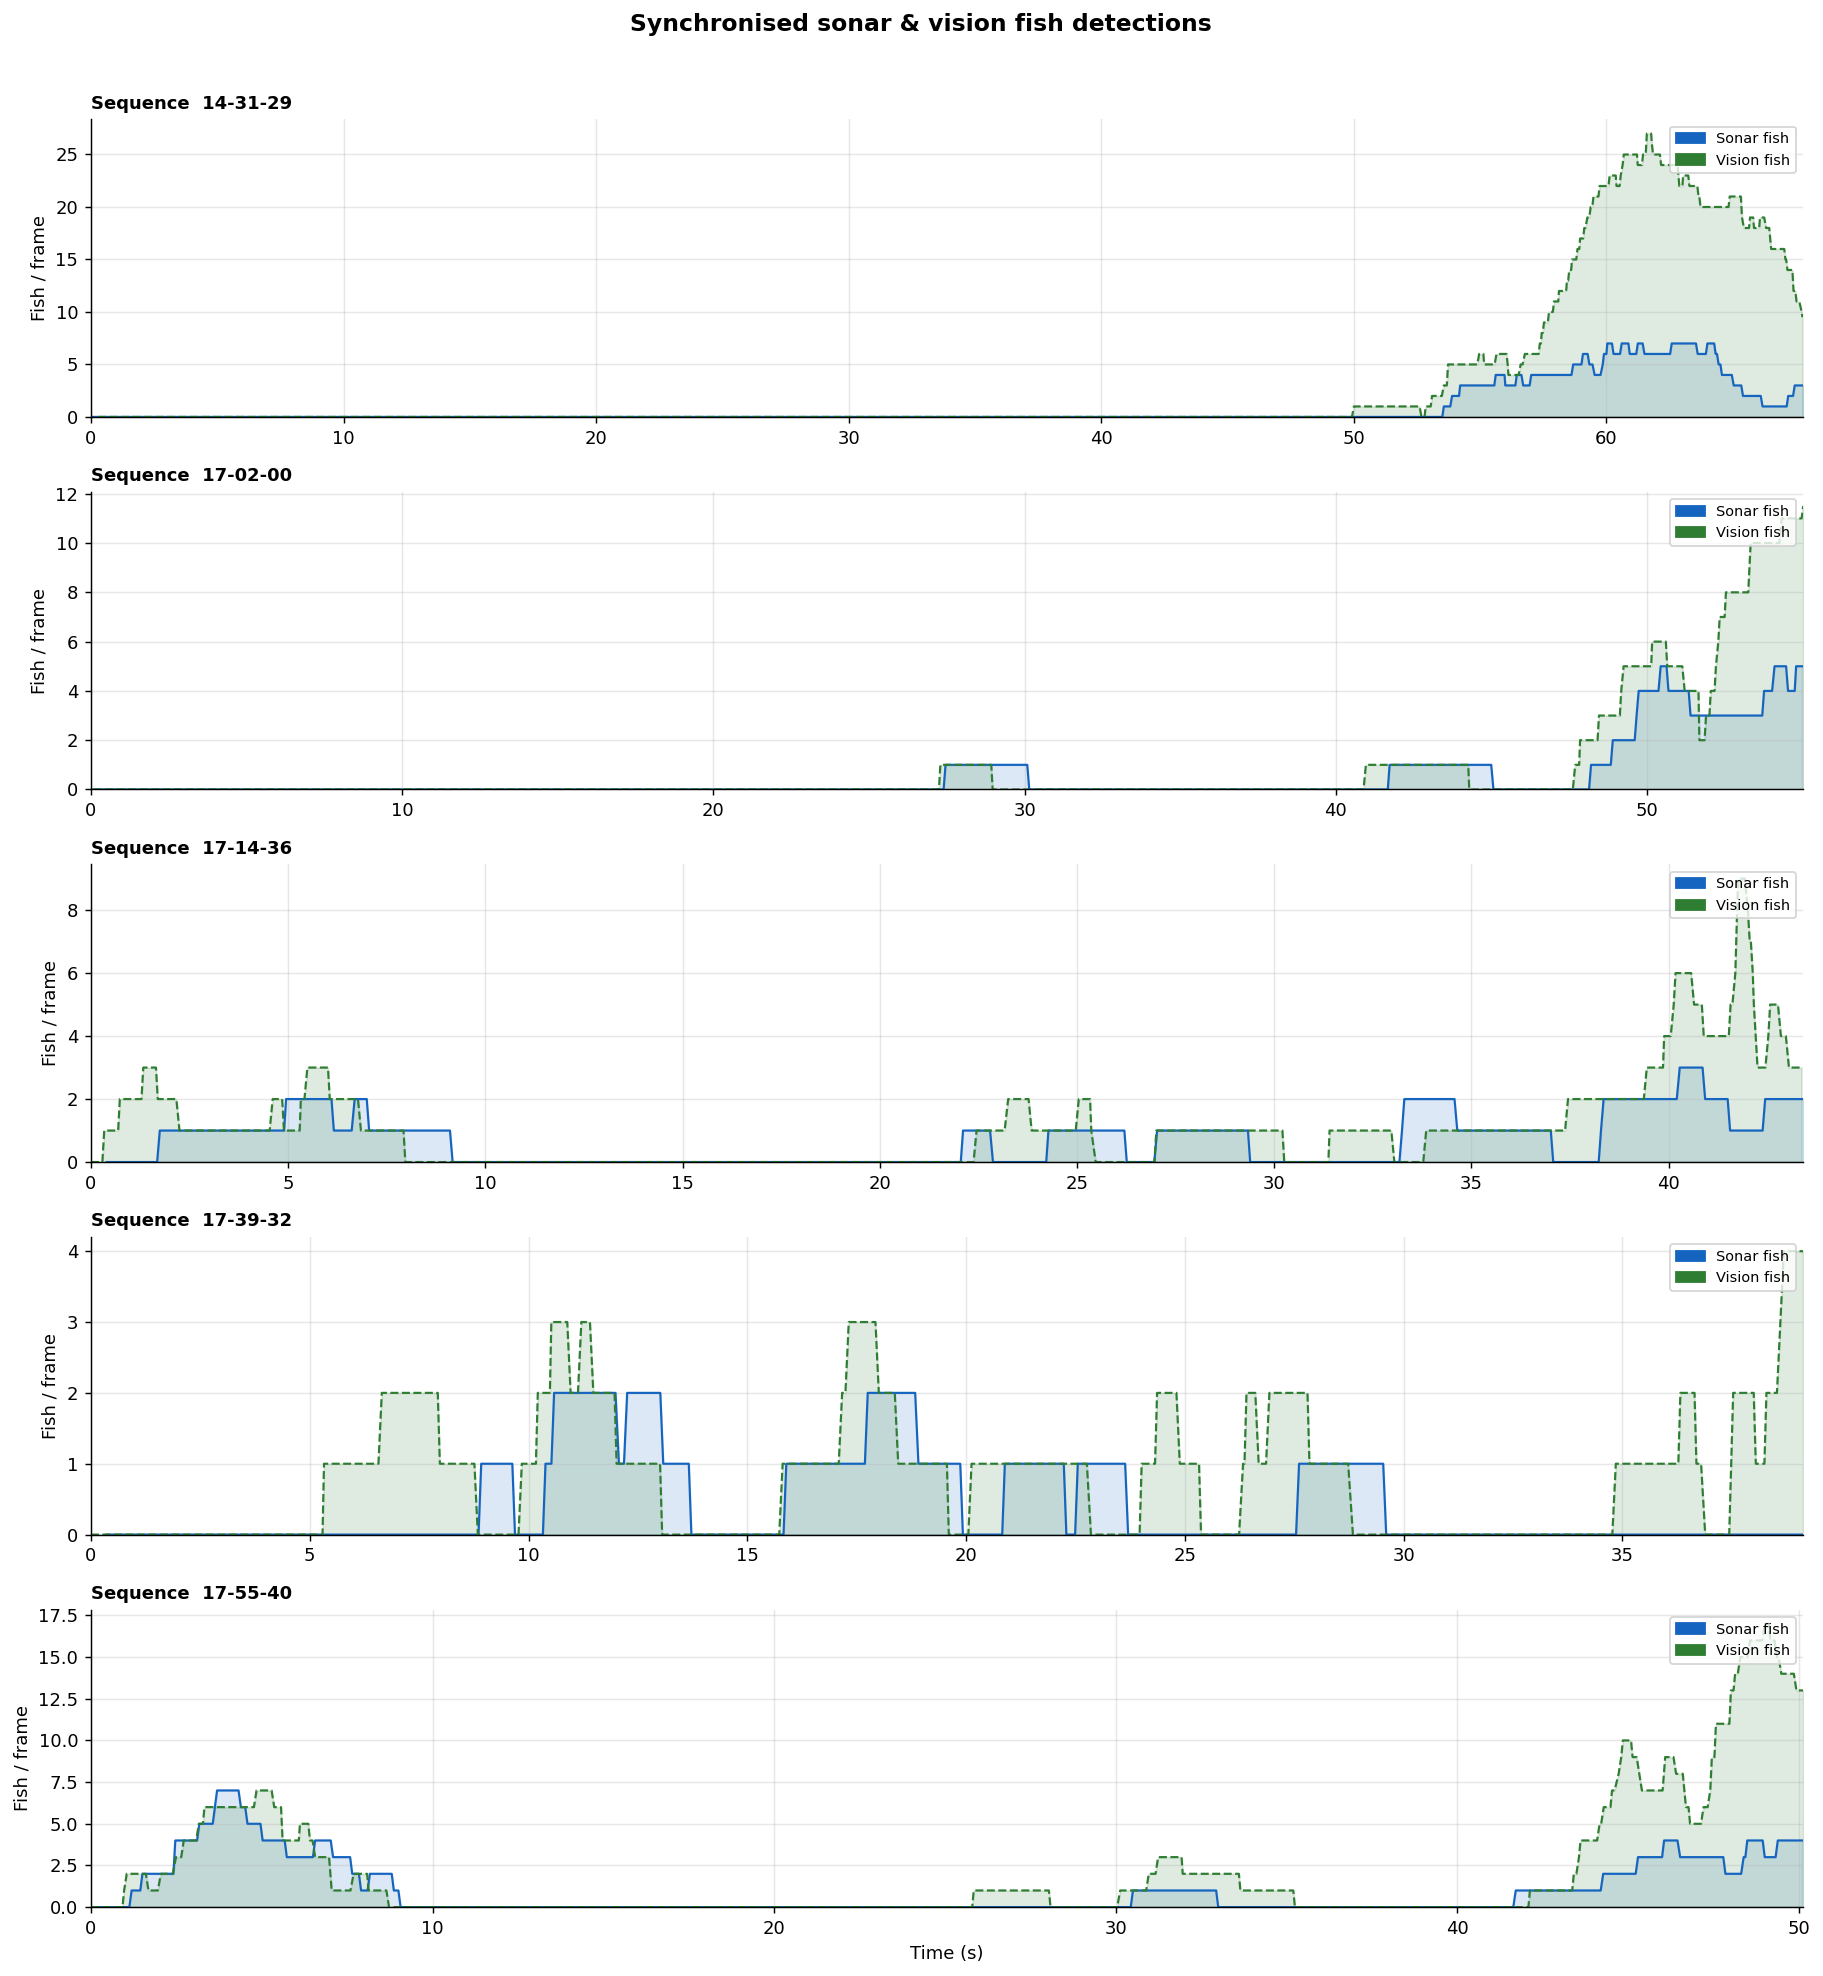

In [5]:
SMOOTH = 7   # rolling-median window for display

fig, axes = plt.subplots(len(SEQUENCES), 1, figsize=(14, 3 * len(SEQUENCES)), sharex=False)

for ax, (seq, d) in zip(axes, seqdata.items()):
    s_fc   = frame_count(d["s"]["df"], d["s"]["tl"], class_id=1)
    v_fc   = frame_count(d["v"]["df"], d["v"]["tl"], class_id=1)
    net_fc = frame_count(d["s"]["df"], d["s"]["tl"], class_id=2)

    s_smooth = s_fc["n"].rolling(SMOOTH, center=True, min_periods=1).median()
    v_smooth = v_fc["n"].rolling(SMOOTH, center=True, min_periods=1).median()

    # # Net presence background shading
    # ax.fill_between(net_fc["time_s"], 0, 1, where=net_fc["n"] > 0,
    #                 transform=ax.get_xaxis_transform(),
    #                 color=C_NET, alpha=0.10, linewidth=0)

    ax.fill_between(s_fc["time_s"],  s_smooth, alpha=0.15, color=C_SONAR)
    ax.fill_between(v_fc["time_s"],  v_smooth, alpha=0.15, color=C_VISION)
    ax.plot(s_fc["time_s"],  s_smooth, lw=1.2, color=C_SONAR,  label="sonar fish")
    ax.plot(v_fc["time_s"],  v_smooth, lw=1.2, color=C_VISION, label="vision fish", ls="--")

    ax.set_ylabel("Fish / frame")
    ax.set_ylim(bottom=0)
    ax.set_xlim(0, d["dur"])
    ax.set_title(f"Sequence  {seq[-8:]}", fontsize=10, fontweight="bold", loc="left")

    handles = [Patch(color=C_SONAR,  label="Sonar fish"),
               Patch(color=C_VISION, label="Vision fish"),
            #    Patch(color=C_NET, alpha=0.4, label="Net present")
            ]
    ax.legend(handles=handles, fontsize=8, loc="upper right")

axes[-1].set_xlabel("Time (s)")
fig.suptitle("Synchronised sonar & vision fish detections", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
# plt.savefig("sync_timeline.png", dpi=150, bbox_inches="tight")
plt.show()

## 2  Detection modality agreement
Each second is classified: both detect fish / sonar only / vision only / neither.

/tmp/ipykernel_3591632/1840276053.py:18: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  agree = pd.concat([s_present, v_present], axis=1).fillna(False)


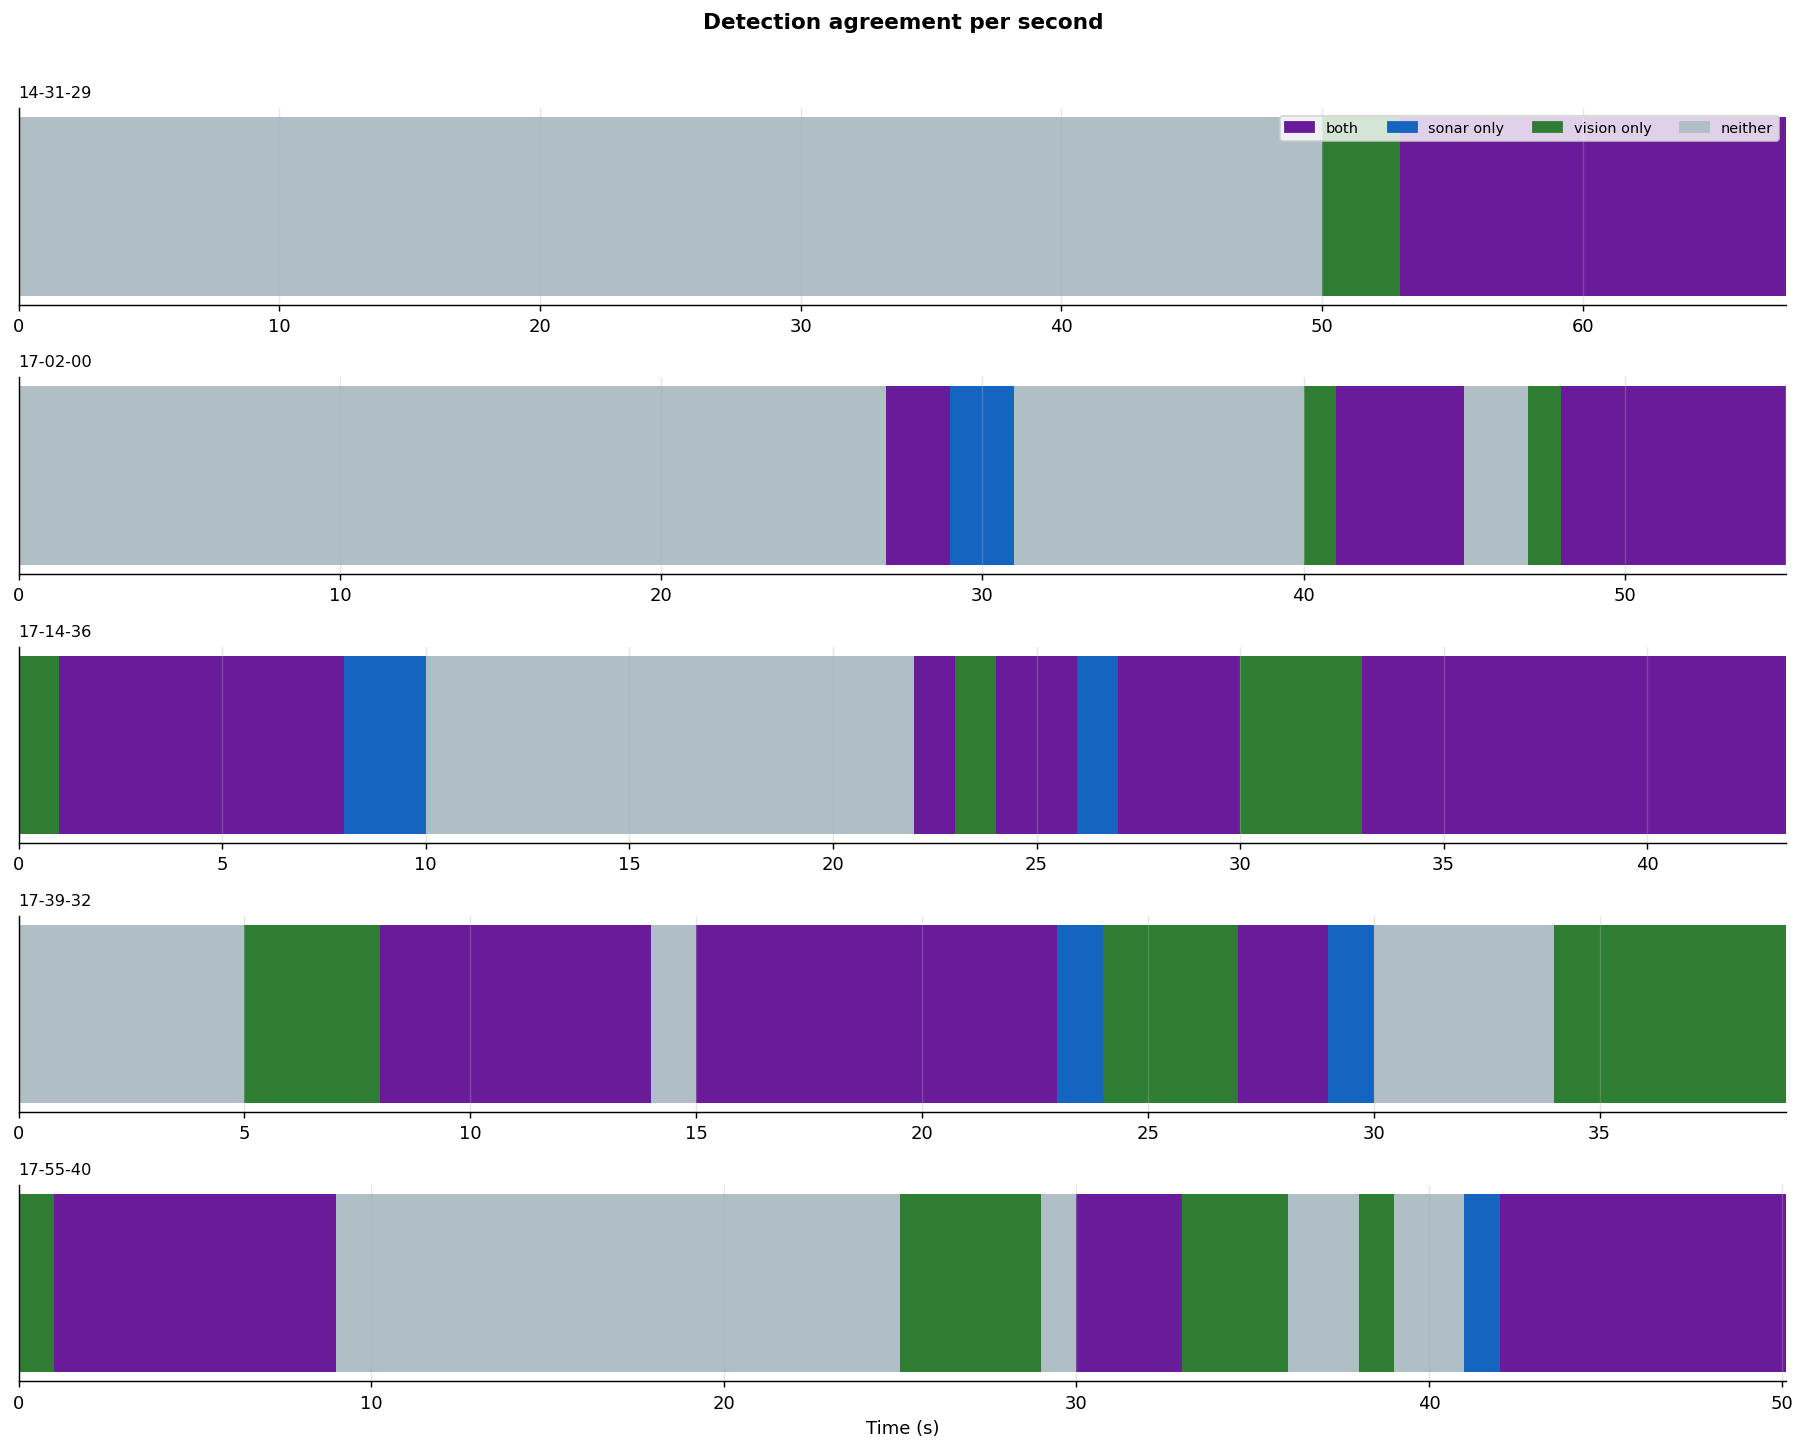

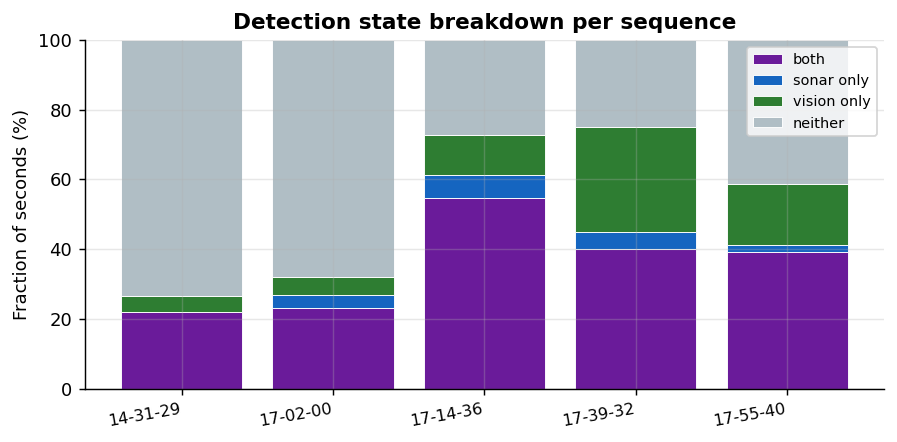

In [6]:
BIN_S = 1.0
STATES = {"both": C_BOTH, "sonar only": C_SONAR, "vision only": C_VISION, "neither": C_NONE}

fig, axes = plt.subplots(len(SEQUENCES), 1, figsize=(14, 2.2 * len(SEQUENCES)))

all_fracs = []

for ax, (seq, d) in zip(axes, seqdata.items()):
    s_fc = frame_count(d["s"]["df"], d["s"]["tl"])
    v_fc = frame_count(d["v"]["df"], d["v"]["tl"])

    edges = np.arange(0, d["dur"] + BIN_S, BIN_S)
    s_bin = pd.cut(s_fc["time_s"], edges, labels=edges[:-1], include_lowest=True).astype(float)
    v_bin = pd.cut(v_fc["time_s"], edges, labels=edges[:-1], include_lowest=True).astype(float)

    s_present = s_fc.groupby(s_bin)["n"].max().rename("s") > 0
    v_present = v_fc.groupby(v_bin)["n"].max().rename("v") > 0
    agree = pd.concat([s_present, v_present], axis=1).fillna(False)

    state = np.where( agree["s"] &  agree["v"], 0,
            np.where( agree["s"] & ~agree["v"], 1,
            np.where(~agree["s"] &  agree["v"], 2, 3)))

    cmap_list = [C_BOTH, C_SONAR, C_VISION, C_NONE]
    colors = [cmap_list[s] for s in state]
    bins_t = agree.index.values

    for t, c in zip(bins_t, colors):
        ax.barh(0, BIN_S, left=t, height=0.8, color=c, linewidth=0)

    ax.set_yticks([])
    ax.set_xlim(0, d["dur"])
    ax.set_title(seq[-8:], fontsize=9, loc="left")

    # Fraction bar chart inset
    fracs = [np.mean(state == i) for i in range(4)]
    all_fracs.append(fracs)

axes[-1].set_xlabel("Time (s)")
legend_handles = [Patch(color=c, label=l) for l, c in STATES.items()]
axes[0].legend(handles=legend_handles, loc="upper right", fontsize=8, ncol=4)
fig.suptitle("Detection agreement per second", fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
# plt.savefig("detection_agreement_timeline.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Fraction summary bar chart ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 3.5))
x = np.arange(len(SEQUENCES))
labels = list(STATES.keys())
colors = list(STATES.values())
bottom = np.zeros(len(SEQUENCES))
for i, (lbl, col) in enumerate(STATES.items()):
    vals = [all_fracs[j][i] * 100 for j in range(len(SEQUENCES))]
    ax.bar(x, vals, bottom=bottom, color=col, label=lbl, edgecolor="white", linewidth=0.5)
    bottom += np.array(vals)

ax.set_xticks(x)
ax.set_xticklabels([s[-8:] for s in SEQUENCES], rotation=10, ha="right", fontsize=9)
ax.set_ylabel("Fraction of seconds (%)")
ax.set_title("Detection state breakdown per sequence", fontweight="bold")
ax.legend(loc="upper right", fontsize=8)
ax.set_ylim(0, 100)
plt.tight_layout()
plt.savefig("detection_agreement_bars.png", dpi=150, bbox_inches="tight")
plt.show()

## 3  Sonar vs vision fish count correlation
1-second bins. Each point is one second of footage; colour = sequence.

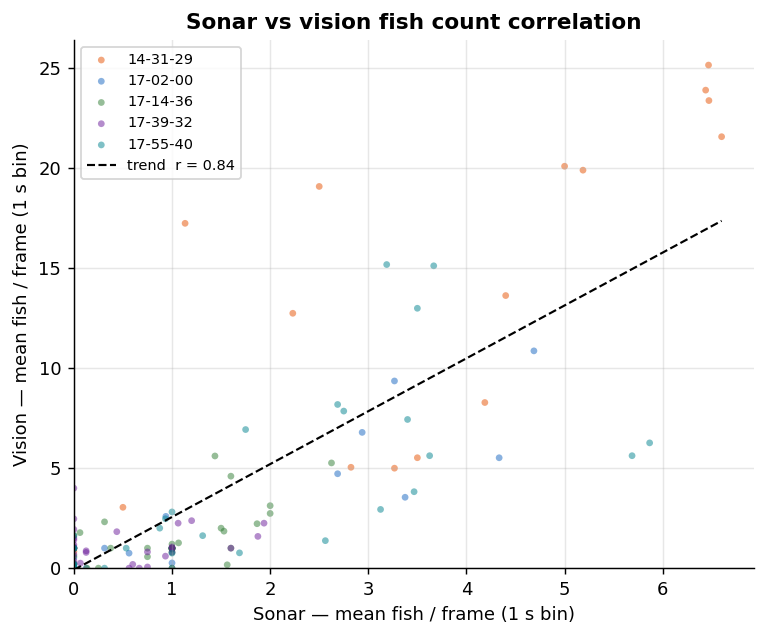

Overall Pearson r = 0.844


In [7]:
fig, ax = plt.subplots(figsize=(6, 5))

all_s, all_v = [], []

for i, (seq, d) in enumerate(seqdata.items()):
    s_fc = frame_count(d["s"]["df"], d["s"]["tl"])
    v_fc = frame_count(d["v"]["df"], d["v"]["tl"])

    s_b = time_bin(s_fc["time_s"], s_fc["n"], bin_s=1.0)
    v_b = time_bin(v_fc["time_s"], v_fc["n"], bin_s=1.0)
    s_b.columns = ["bin", "s"]
    v_b.columns = ["bin", "v"]
    merged = s_b.merge(v_b, on="bin")

    ax.scatter(merged["s"], merged["v"], s=14, alpha=0.5, color=SEQ_COLS[i],
               label=seq[-8:], edgecolors="none")
    all_s.extend(merged["s"].tolist())
    all_v.extend(merged["v"].tolist())

all_s, all_v = np.array(all_s), np.array(all_v)
r = np.corrcoef(all_s, all_v)[0, 1]

# Trend line
m, b = np.polyfit(all_s, all_v, 1)
xs = np.linspace(0, all_s.max(), 100)
ax.plot(xs, m*xs + b, color="black", lw=1.2, ls="--", label=f"trend  r = {r:.2f}")

ax.set_xlabel("Sonar — mean fish / frame (1 s bin)")
ax.set_ylabel("Vision — mean fish / frame (1 s bin)")
ax.set_title("Sonar vs vision fish count correlation", fontweight="bold")
ax.legend(fontsize=8)
ax.set_xlim(left=0); ax.set_ylim(bottom=0)
plt.tight_layout()
# plt.savefig("correlation_sonar_vision.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Overall Pearson r = {r:.3f}")

## 4  Fish clustering over time (sonar, DBSCAN)
DBSCAN on physical (x_m, y_m) sonar coordinates each frame.  
`eps = 0.4 m`, `min_samples = 2`.  
**Shoaling fraction** = fraction of fish in a cluster with ≥ 2 members.

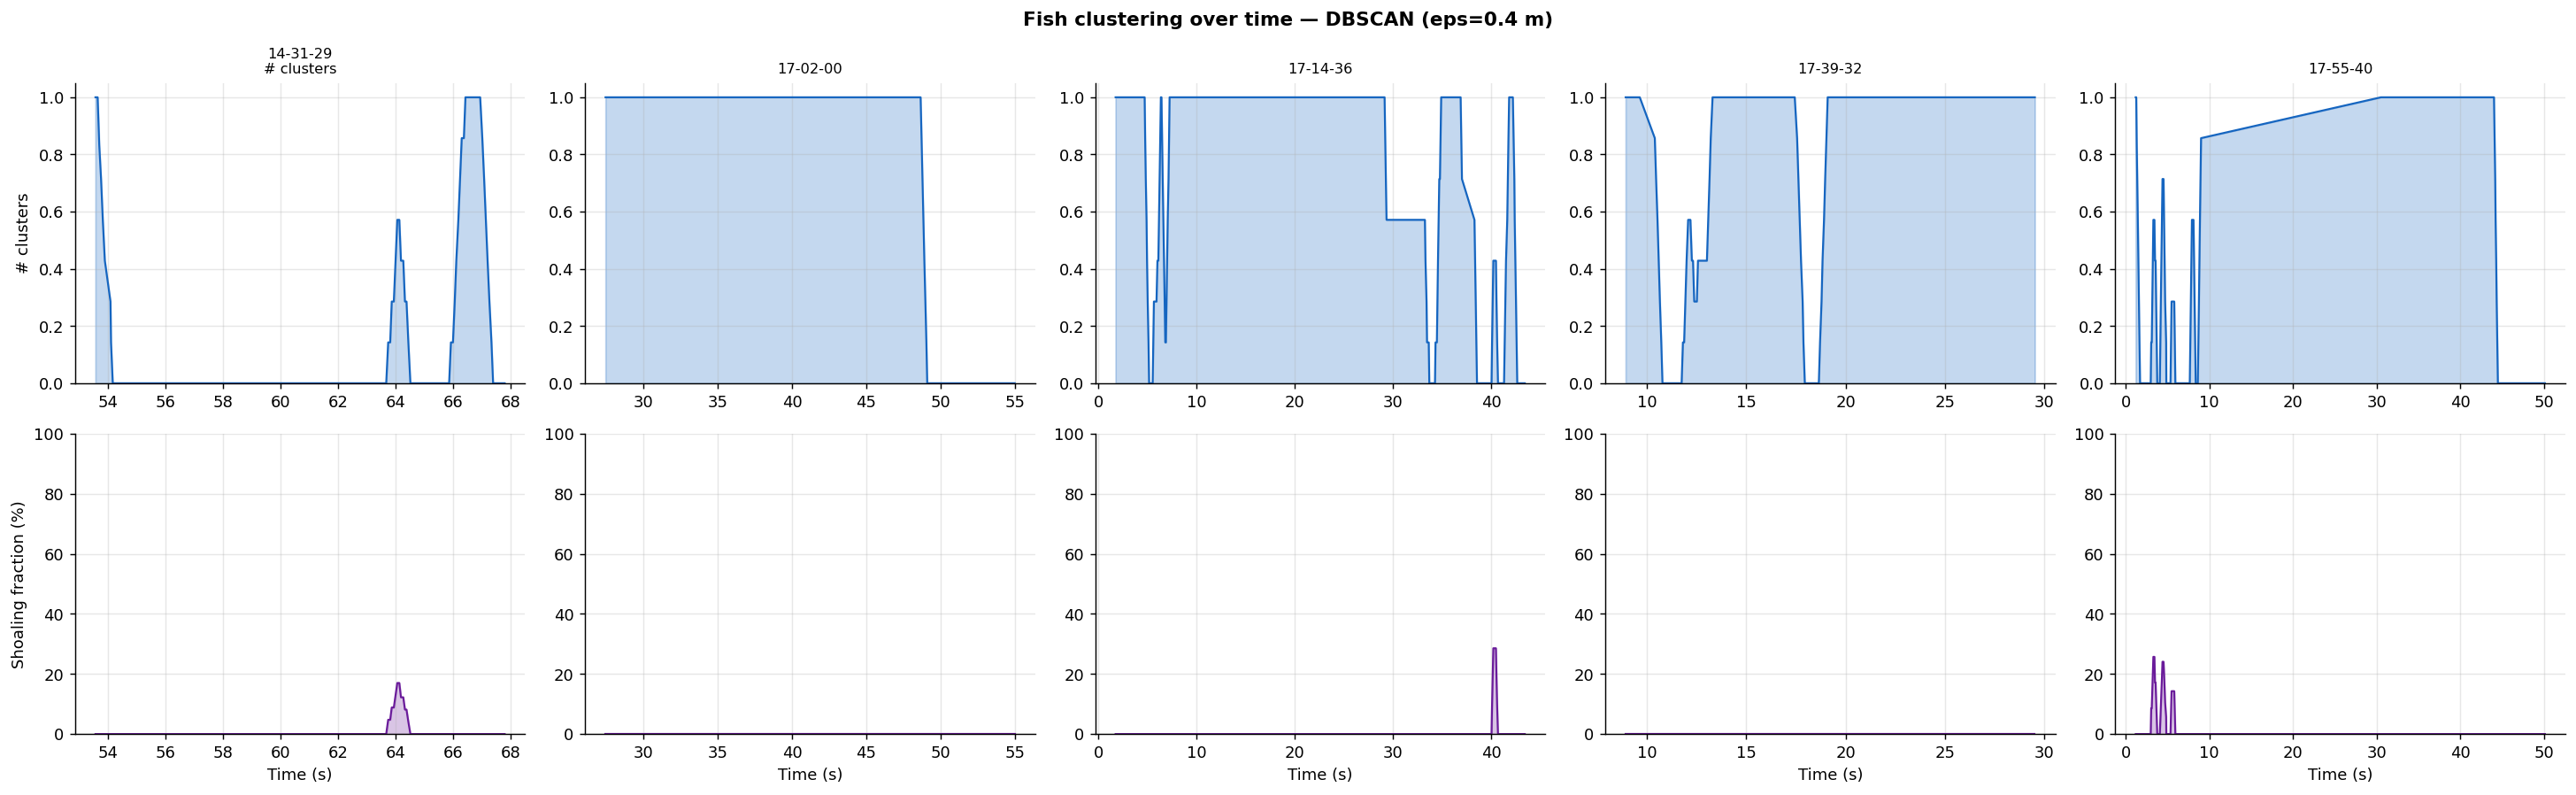

In [8]:
if not HAS_SKLEARN:
    print("Skipping — scikit-learn not available")
else:
    EPS_M, MIN_S = 0.4, 2

    def cluster_per_frame(s_df):
        rows = []
        for (seq, fn), grp in s_df[s_df["class_id"]==1].groupby(["sequence","frame_norm"]):
            pts = grp[["x_m","y_m"]].values
            n   = len(pts)
            if n < 2:
                rows.append({"sequence":seq,"frame_norm":fn,"n_fish":n,
                             "n_clusters":min(n,1),"shoaling_frac":0.0,"largest":n})
                continue
            lbl  = DBSCAN(eps=EPS_M, min_samples=MIN_S).fit_predict(pts)
            good = lbl[lbl >= 0]
            nc   = len(set(good))
            lg   = int(np.bincount(good).max()) if len(good) else 0
            rows.append({"sequence":seq,"frame_norm":fn,"n_fish":n,
                         "n_clusters":nc,"shoaling_frac":len(good)/n,"largest":lg})
        return pd.DataFrame(rows)

    fig, axes = plt.subplots(2, len(SEQUENCES), figsize=(4.5*len(SEQUENCES), 7))

    for col, (seq, d) in enumerate(seqdata.items()):
        s_df = d["s"]["df"]
        s_tl = d["s"]["tl"]
        cl   = cluster_per_frame(s_df)
        cl   = cl.merge(s_tl[["frame_norm","time_s"]], on="frame_norm", how="left")

        sm_nc = cl["n_clusters"].rolling(7,   center=True, min_periods=1).mean()
        sm_sf = cl["shoaling_frac"].rolling(7, center=True, min_periods=1).mean()

        # Top: n_clusters over time
        ax = axes[0, col]
        ax.fill_between(cl["time_s"], sm_nc, alpha=0.25, color=C_SONAR)
        ax.plot(cl["time_s"], sm_nc, lw=1.2, color=C_SONAR)
        ax.set_title(seq[-8:], fontsize=9)
        ax.set_ylim(bottom=0)
        if col == 0: ax.set_ylabel("# clusters")

        # Bottom: shoaling fraction over time
        ax2 = axes[1, col]
        ax2.fill_between(cl["time_s"], sm_sf*100, alpha=0.25, color=C_BOTH)
        ax2.plot(cl["time_s"], sm_sf*100, lw=1.2, color=C_BOTH)
        ax2.set_ylim(0, 100); ax2.set_xlabel("Time (s)")
        if col == 0: ax2.set_ylabel("Shoaling fraction (%)")

    axes[0,0].set_title(f"{SEQUENCES[0][-8:]}\n# clusters", fontsize=9)
    fig.suptitle(f"Fish clustering over time — DBSCAN (eps={EPS_M} m)",
                 fontsize=12, fontweight="bold")
    plt.tight_layout()
    # plt.savefig("fish_clustering_time.png", dpi=150, bbox_inches="tight")
    plt.show()

## 5  Spatial fish density — top-down physical space (sonar)
All sequences combined. Net median position per sequence shown as a dashed line.

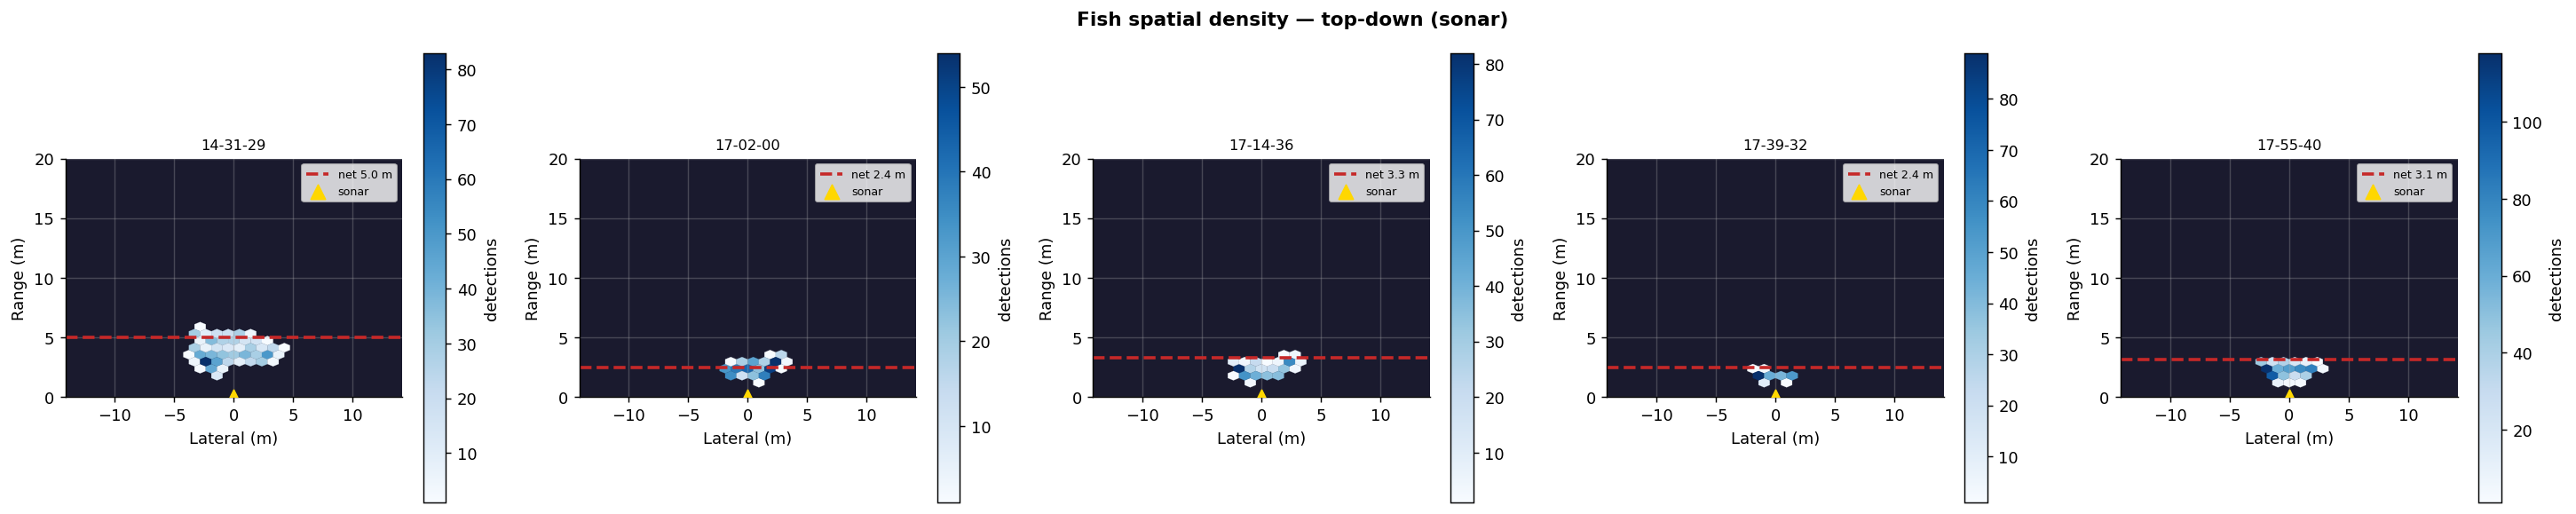

In [9]:
fig, axes = plt.subplots(1, len(SEQUENCES), figsize=(4.5*len(SEQUENCES), 4.5))

for ax, (seq, d) in zip(axes, seqdata.items()):
    s_df = d["s"]["df"]
    fish = s_df[s_df["class_id"]==1]
    net  = s_df[s_df["class_id"]==2]

    hb = ax.hexbin(fish["x_m"], fish["y_m"],
                   gridsize=30, cmap="Blues",
                   extent=[-S_XSPAN_M, S_XSPAN_M, 0, S_YMAX_M],
                   mincnt=1, linewidths=0.1)
    plt.colorbar(hb, ax=ax, label="detections")

    if not net.empty:
        net_y = net["y_m"].median()
        ax.axhline(net_y, color=C_NET, lw=2, ls="--", label=f"net {net_y:.1f} m")

    # ROV marker at origin (bottom)
    ax.scatter(0, 0, s=80, marker="^", color="gold", zorder=5, label="sonar")

    ax.set_xlim(-S_XSPAN_M, S_XSPAN_M)
    ax.set_ylim(0, S_YMAX_M)
    ax.set_xlabel("Lateral (m)")
    ax.set_ylabel("Range (m)")
    ax.set_title(seq[-8:], fontsize=9)
    ax.set_aspect("equal")
    ax.legend(fontsize=7)
    ax.set_facecolor("#1a1a2e")

fig.suptitle("Fish spatial density — top-down (sonar)", fontsize=12, fontweight="bold")
plt.tight_layout()
# plt.savefig("fish_spatial_density_topdown.png", dpi=150, bbox_inches="tight")
plt.show()

## 6  Fish proximity to net over time (sonar)
Per frame: fraction of fish within 0.5 m / 1.0 m / 2.0 m of the net bbox centre.

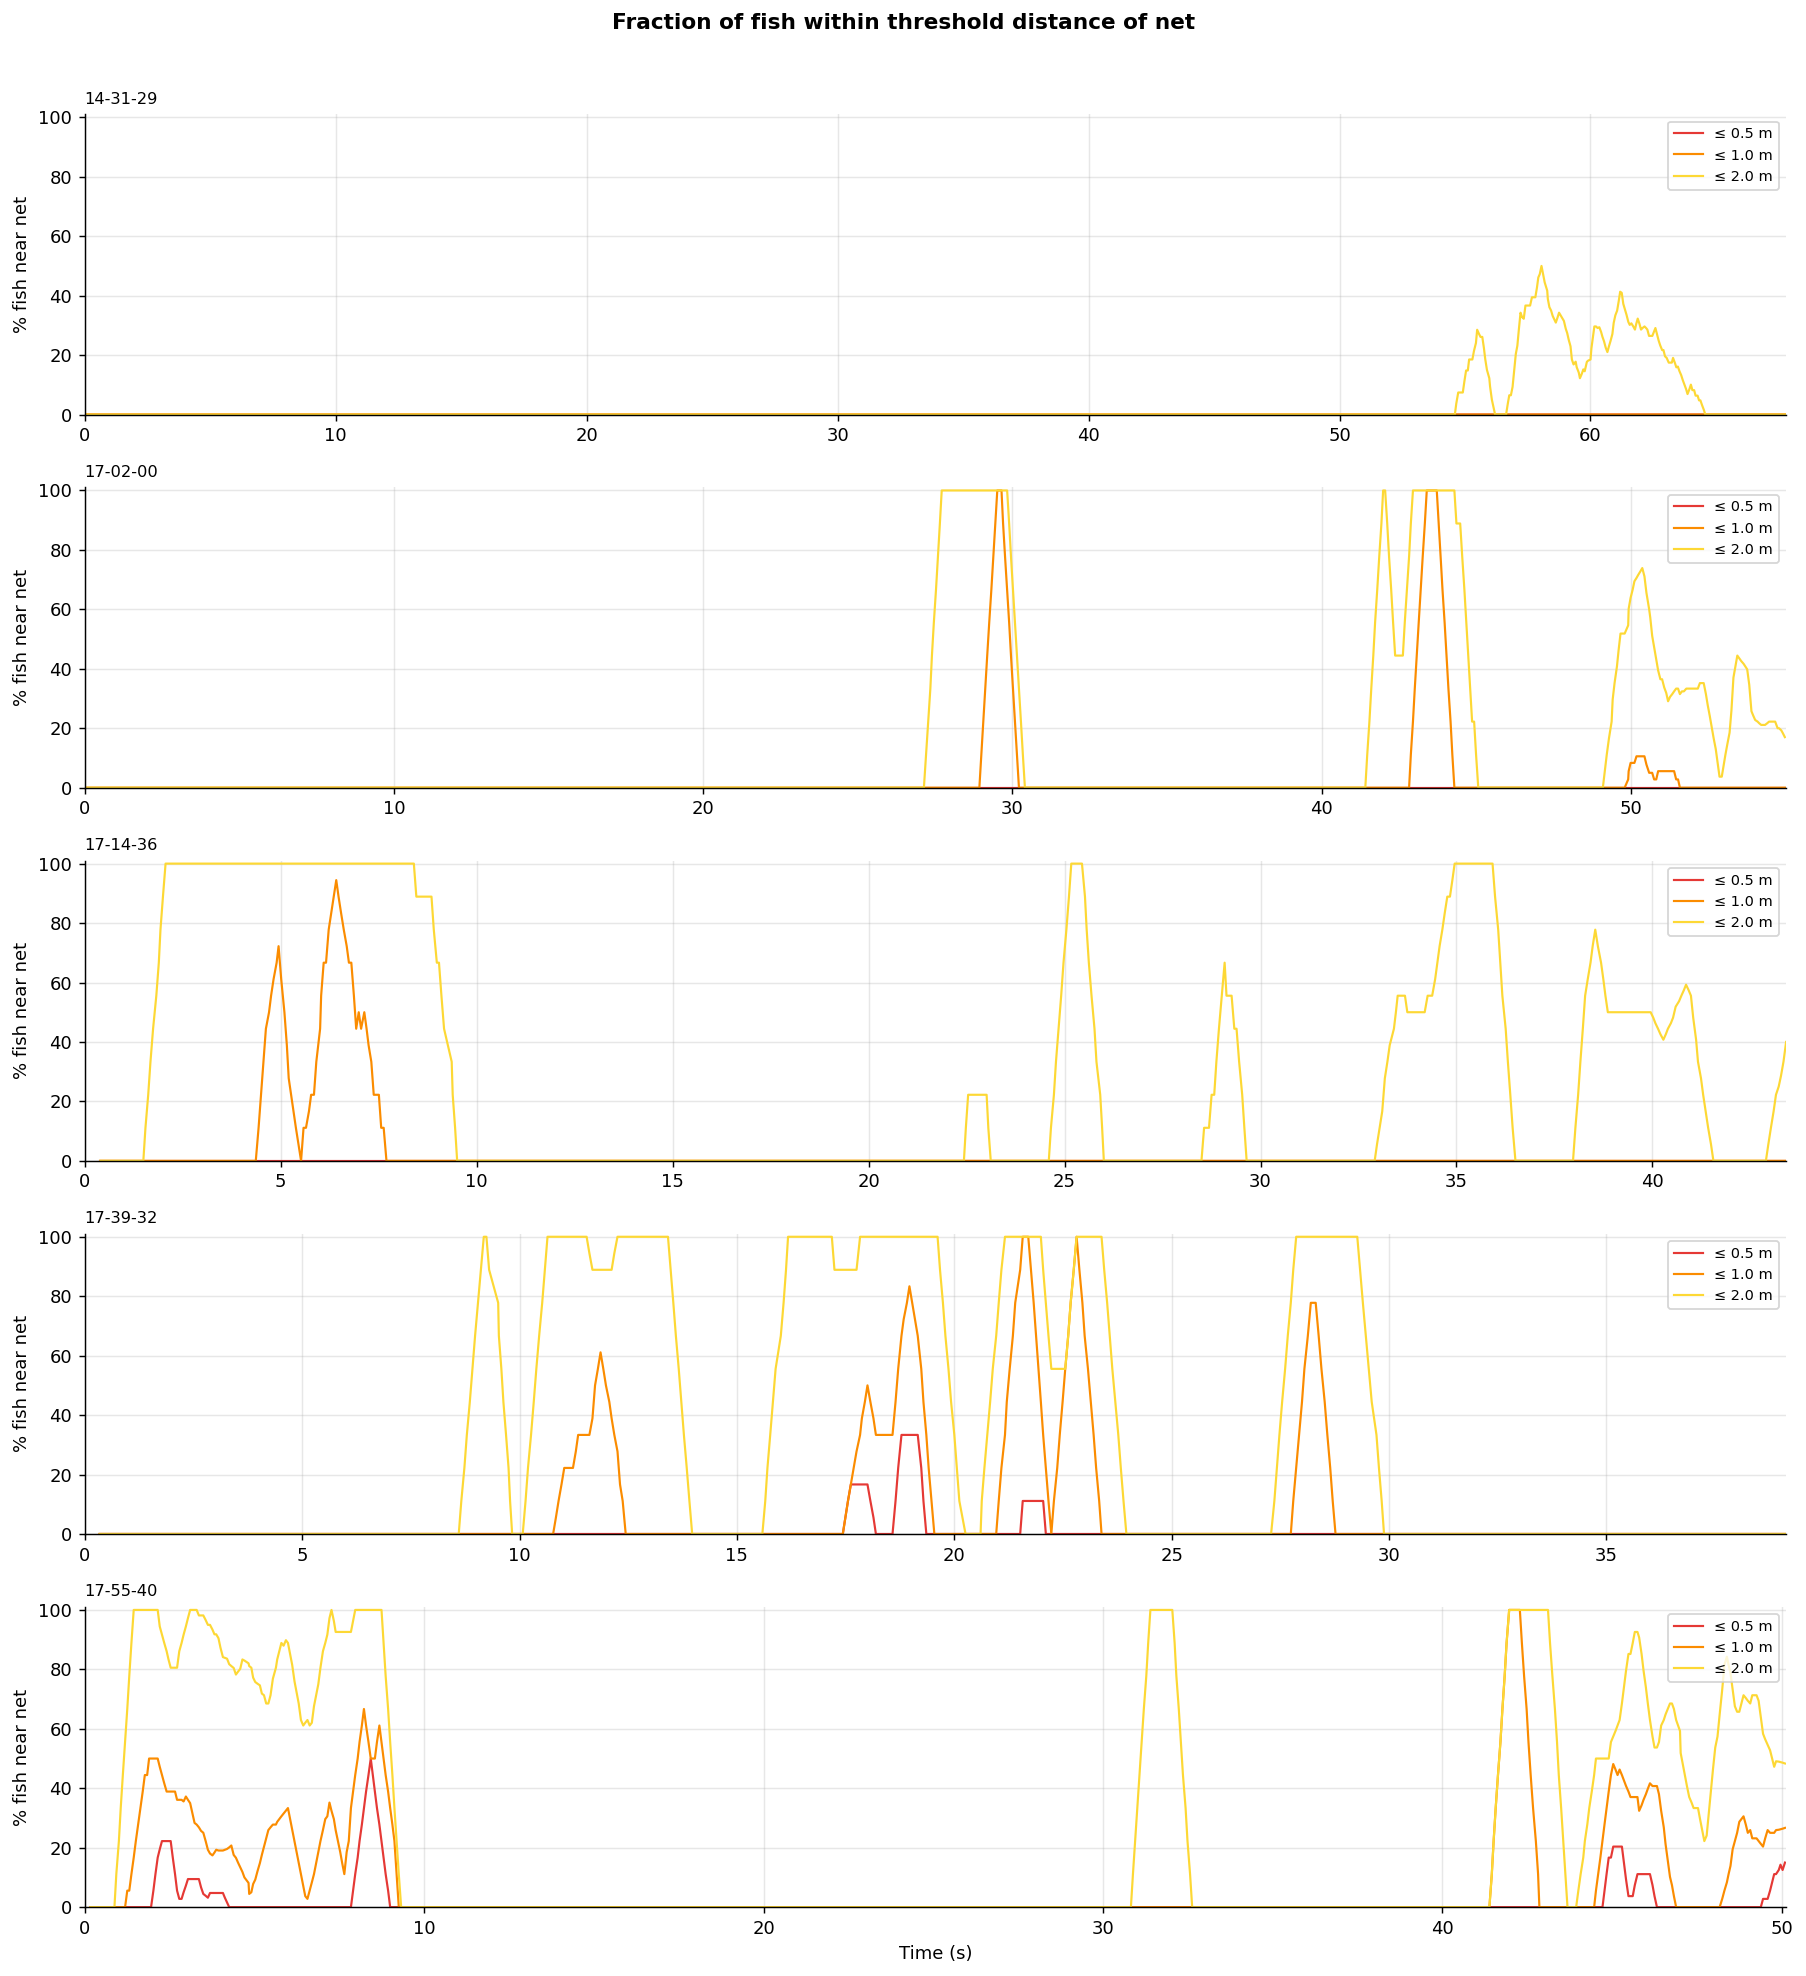

In [10]:
THRESHOLDS = [0.5, 1.0, 2.0]
THR_COLS   = ["#E53935", "#FB8C00", "#FDD835"]  # red / orange / yellow

fig, axes = plt.subplots(len(SEQUENCES), 1, figsize=(14, 3*len(SEQUENCES)))

for ax, (seq, d) in zip(axes, seqdata.items()):
    s_df = d["s"]["df"]
    s_tl = d["s"]["tl"]
    fish = s_df[s_df["class_id"]==1]
    net  = s_df[s_df["class_id"]==2]

    if net.empty or fish.empty:
        ax.set_title(f"{seq[-8:]} — insufficient data", fontsize=9)
        continue

    # Net centre per frame
    net_pos = net.groupby("frame_norm")[["x_m","y_m"]].mean().rename(
              columns={"x_m":"nx","y_m":"ny"})
    mf = fish.join(net_pos, on="frame_norm").dropna(subset=["nx"])
    mf["d2net"] = np.sqrt((mf["x_m"]-mf["nx"])**2 + (mf["y_m"]-mf["ny"])**2)

    for thr, col in zip(THRESHOLDS, THR_COLS):
        near  = (mf["d2net"] <= thr).groupby(mf["frame_norm"]).mean().reset_index()
        near.columns = ["frame_norm","frac"]
        tl2   = s_tl.merge(near, on="frame_norm", how="left")
        tl2["frac"] = tl2["frac"].fillna(0)
        sm = tl2["frac"].rolling(9, center=True, min_periods=1).mean()
        ax.plot(tl2["time_s"], sm*100, lw=1.2, color=col, label=f"≤ {thr} m")

    ax.set_ylabel("% fish near net")
    ax.set_ylim(0, 101)
    ax.set_xlim(0, d["dur"])
    ax.set_title(seq[-8:], fontsize=9, loc="left")
    ax.legend(fontsize=8, loc="upper right")

axes[-1].set_xlabel("Time (s)")
fig.suptitle("Fraction of fish within threshold distance of net",
             fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
# plt.savefig("fish_proximity_to_net.png", dpi=150, bbox_inches="tight")
plt.show()

## 7  Net distance & fish count — dual-axis
Net range from sonar (left axis) and sonar + vision fish counts (right axis) on the same time axis.

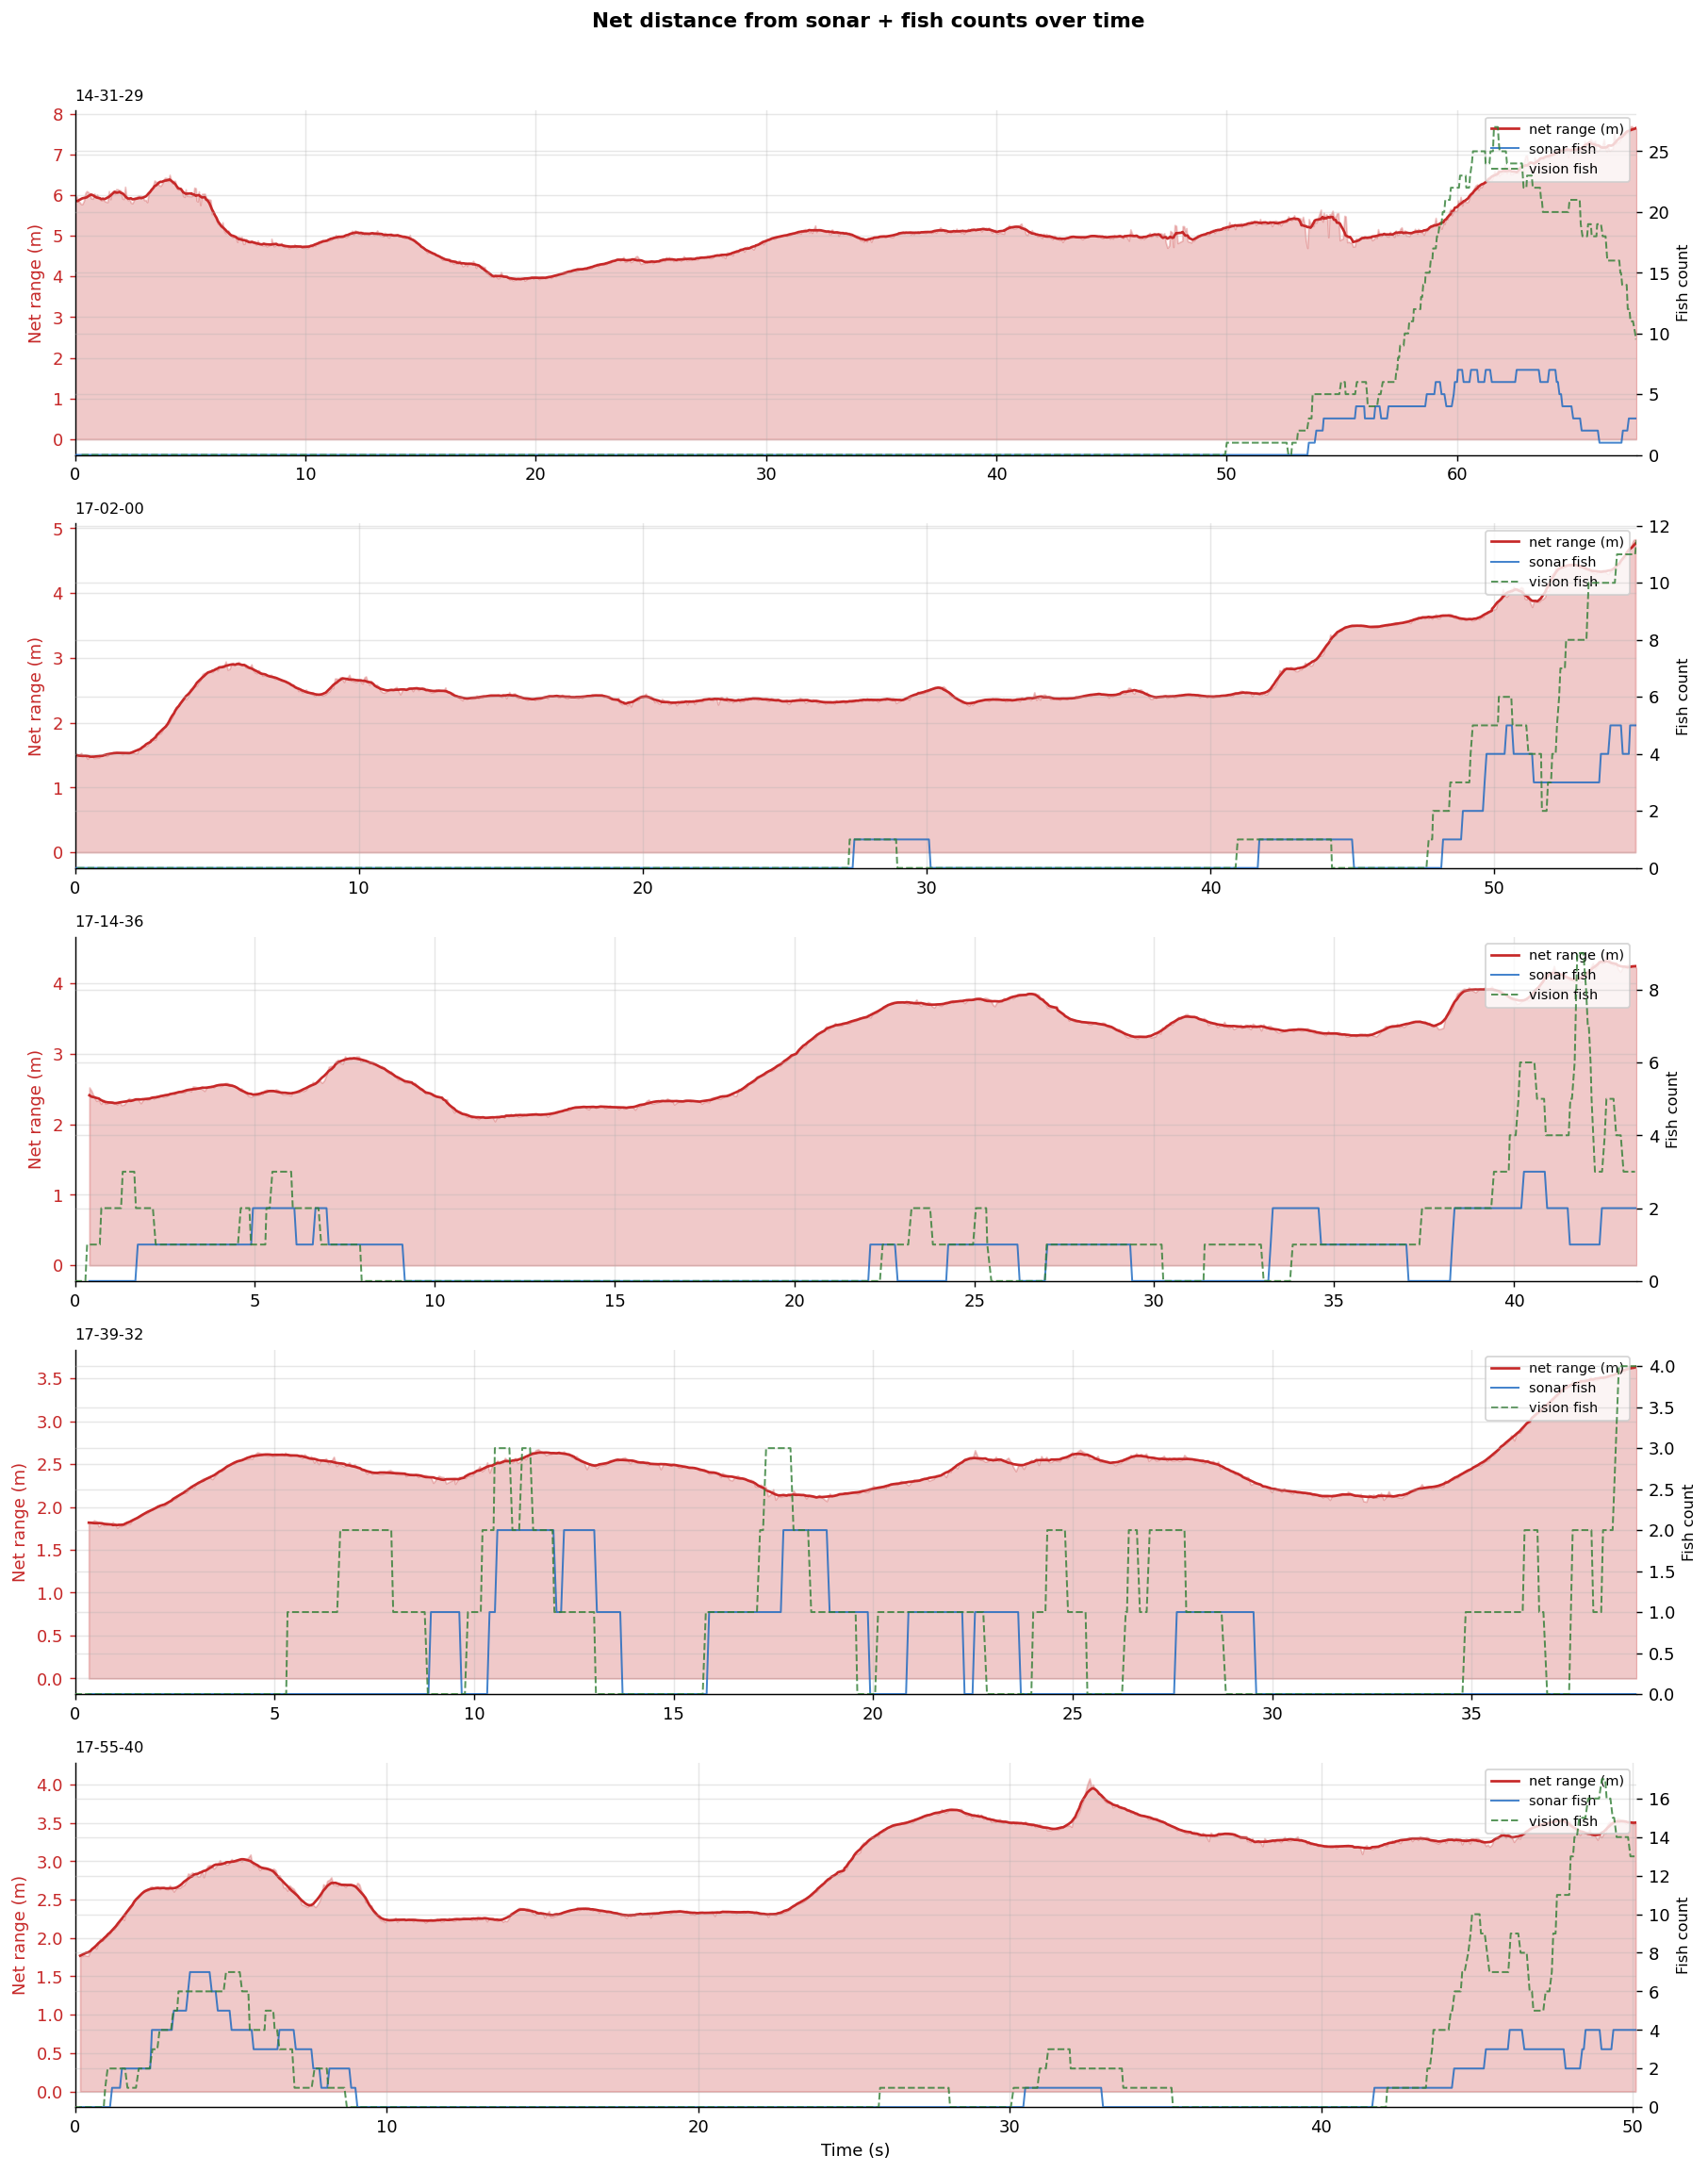

In [11]:
fig, axes = plt.subplots(len(SEQUENCES), 1, figsize=(14, 3.5*len(SEQUENCES)))

for ax, (seq, d) in zip(axes, seqdata.items()):
    s_df = d["s"]["df"]
    s_tl = d["s"]["tl"]
    v_fc = frame_count(d["v"]["df"], d["v"]["tl"])
    net  = s_df[s_df["class_id"]==2]

    # Net range (median per frame, merged to full sonar timeline)
    if not net.empty:
        nr = net.groupby("frame_norm")["range_m"].median().reset_index()
        net_tl = s_tl.merge(nr, on="frame_norm", how="left")
        ax.fill_between(net_tl["time_s"], net_tl["range_m"],
                        alpha=0.25, color=C_NET, label="_")
        ax.plot(net_tl["time_s"],
                net_tl["range_m"].rolling(9, center=True, min_periods=1).mean(),
                color=C_NET, lw=1.5, label="net range (m)")
        ax.set_ylabel("Net range (m)", color=C_NET)
        ax.tick_params(axis="y", colors=C_NET)

    # Fish counts on twin axis
    ax2 = ax.twinx()
    s_fc = frame_count(s_df, s_tl)
    ax2.plot(s_fc["time_s"],
             s_fc["n"].rolling(7, center=True, min_periods=1).median(),
             color=C_SONAR, lw=1.1, alpha=0.8, label="sonar fish")
    ax2.plot(v_fc["time_s"],
             v_fc["n"].rolling(7, center=True, min_periods=1).median(),
             color=C_VISION, lw=1.1, alpha=0.8, ls="--", label="vision fish")
    ax2.set_ylabel("Fish count", fontsize=9)
    ax2.set_ylim(bottom=0)
    ax2.spines[["top","bottom","left"]].set_visible(False)

    ax.set_xlim(0, d["dur"])
    ax.set_title(seq[-8:], fontsize=9, loc="left")

    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1+h2, l1+l2, fontsize=8, loc="upper right")

axes[-1].set_xlabel("Time (s)")
fig.suptitle("Net distance from sonar + fish counts over time",
             fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
# plt.savefig("net_range_fish_count.png", dpi=150, bbox_inches="tight")
plt.show()

## 8  Fish cluster snapshots in physical space
Four time snapshots per sequence showing DBSCAN cluster assignments in (x_m, y_m) space.  
Each colour = one cluster; grey = unclustered fish; dashed = net position.

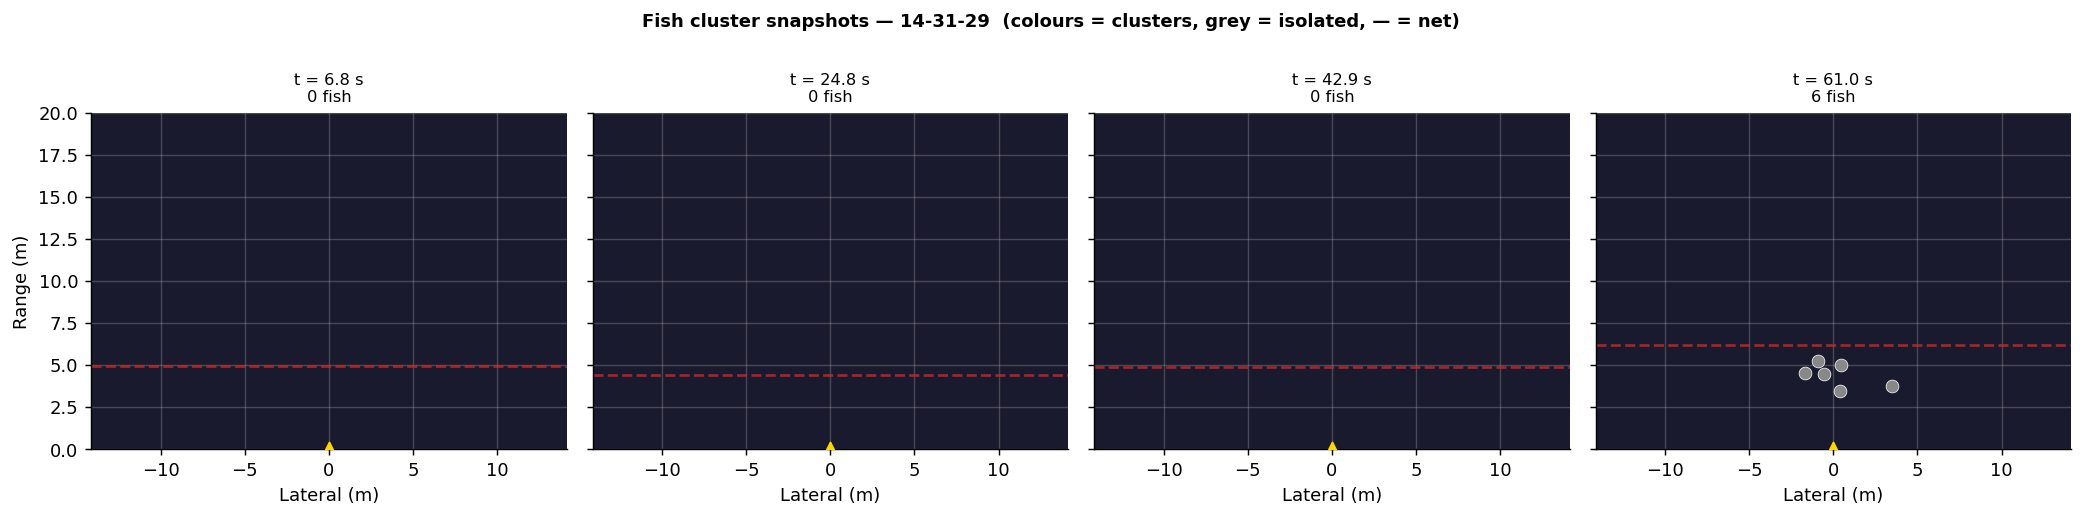

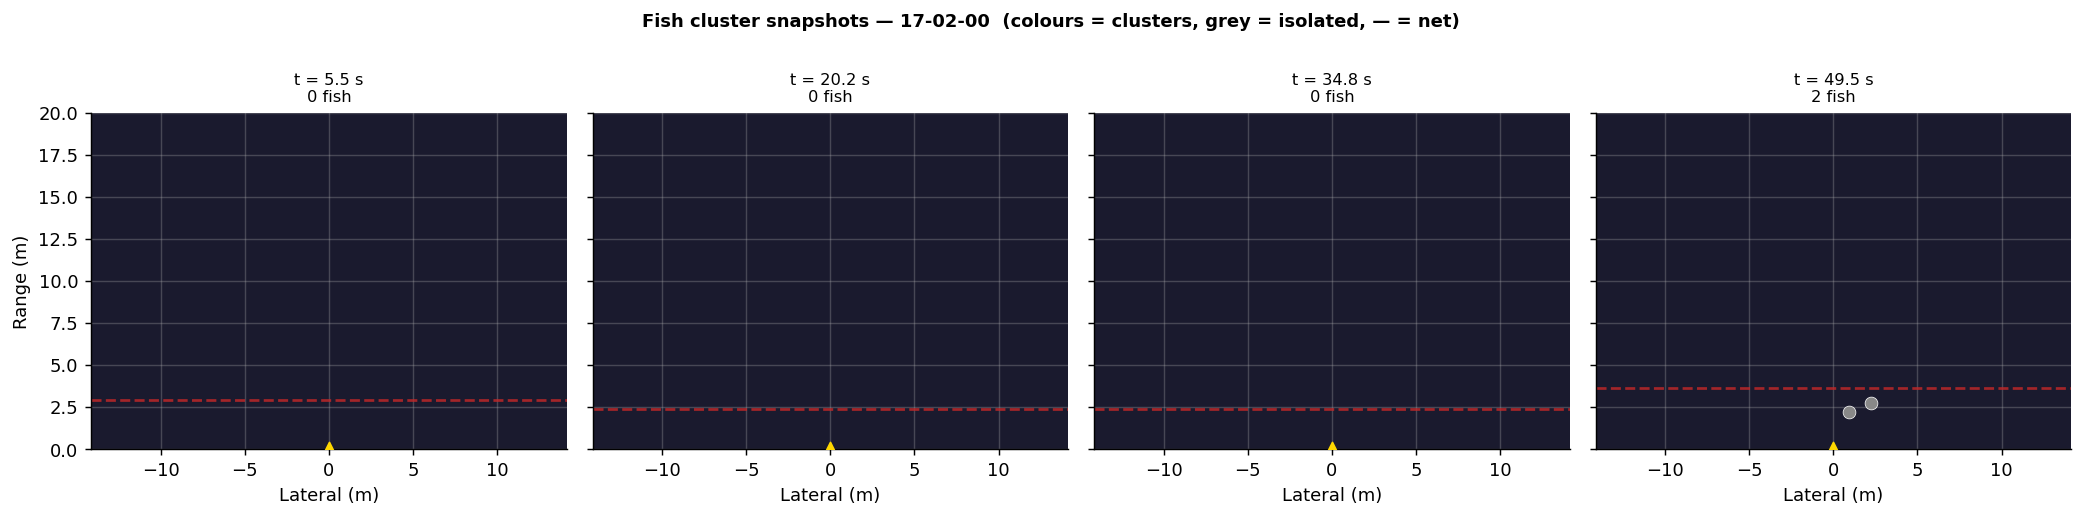

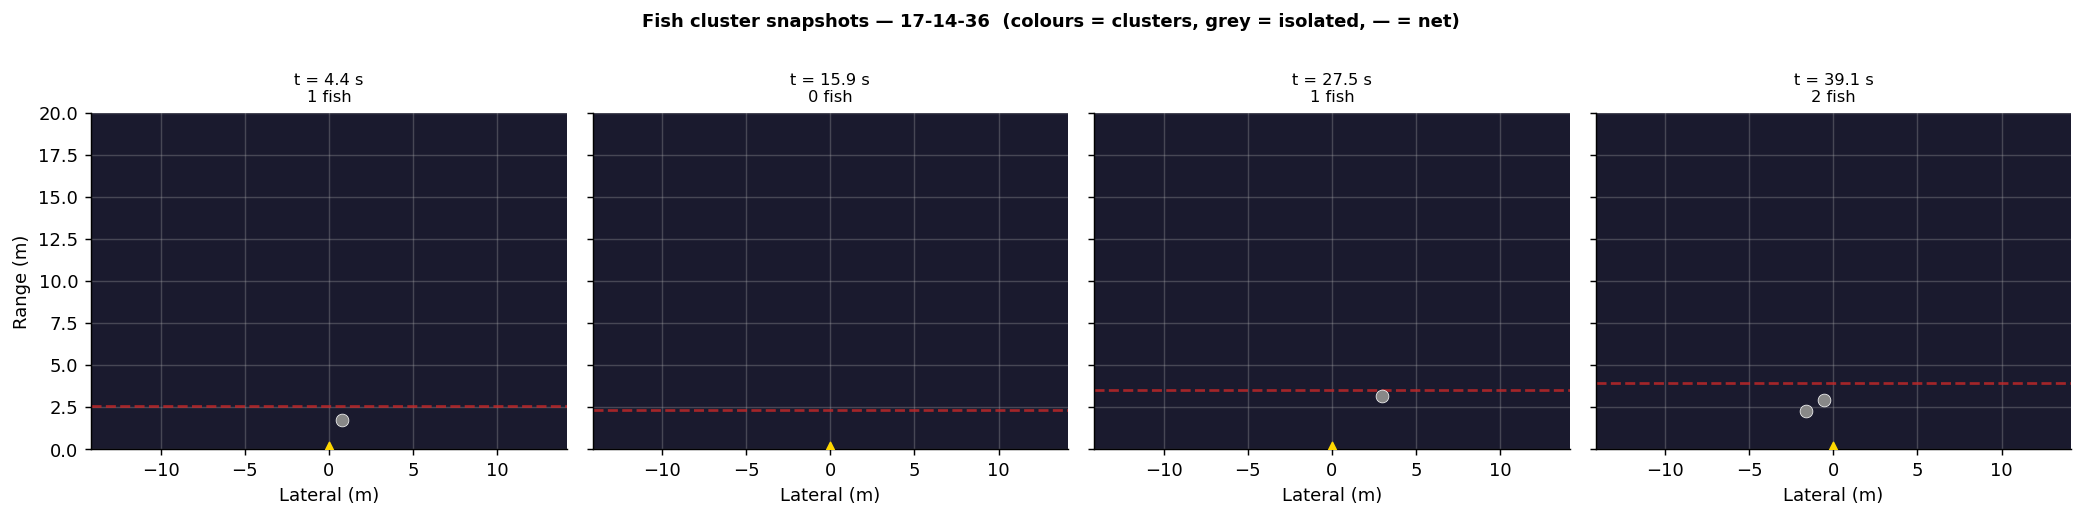

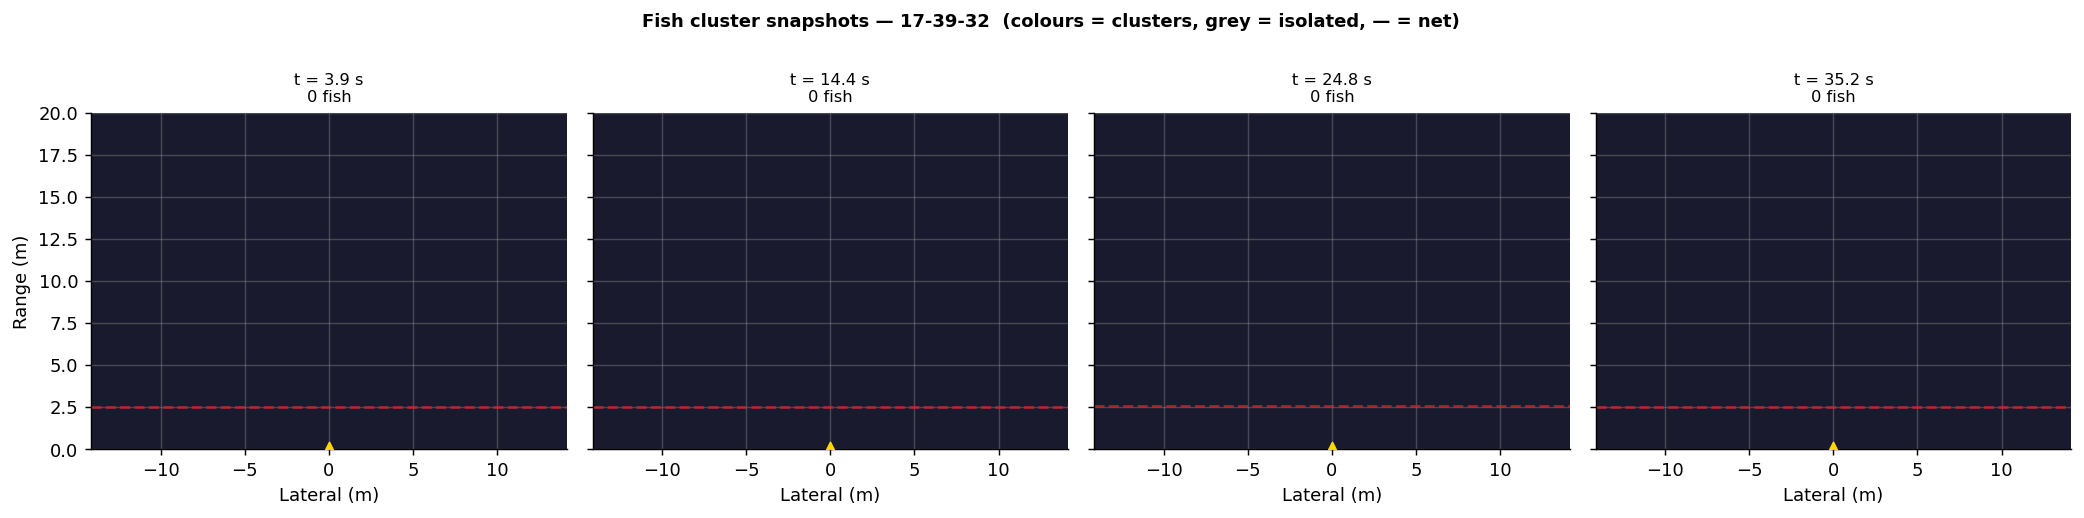

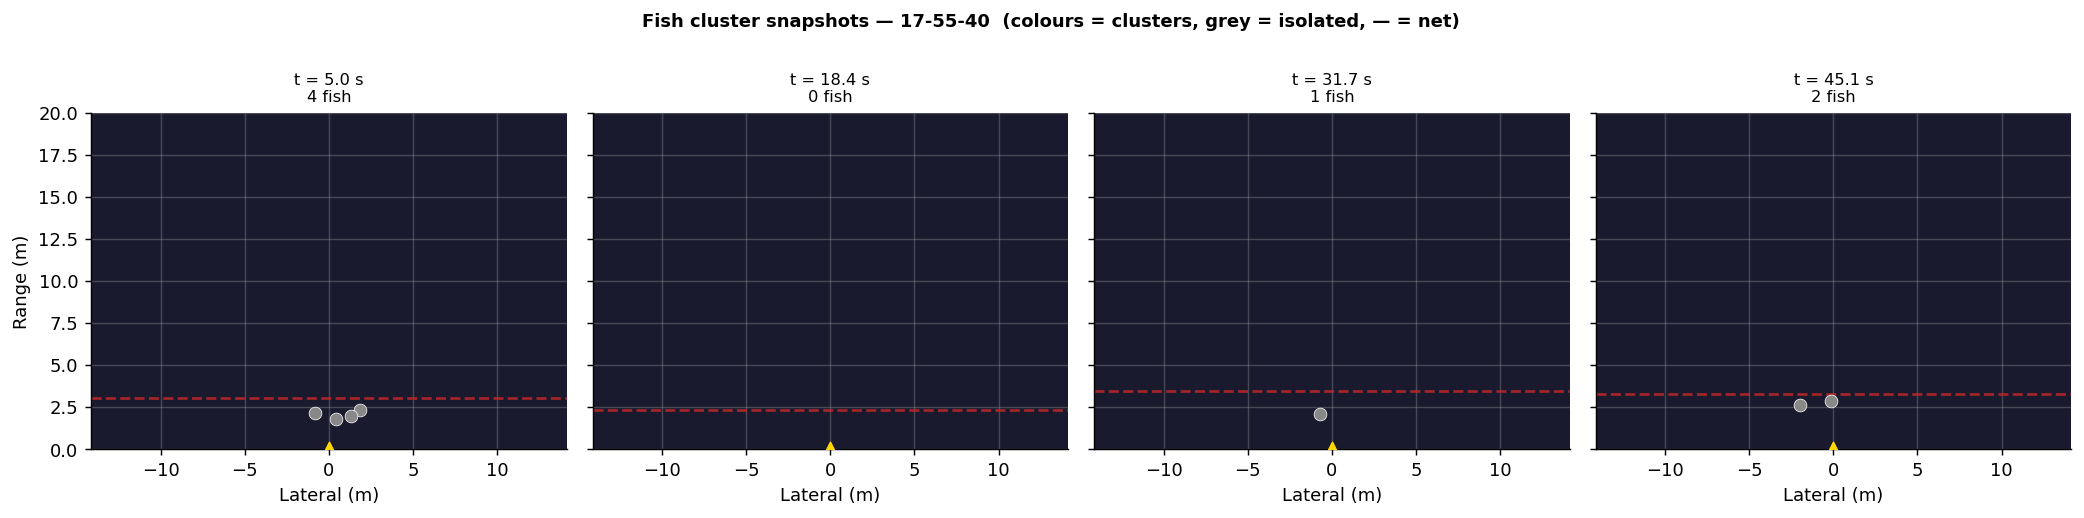

In [12]:
if not HAS_SKLEARN:
    print("Skipping — scikit-learn not available")
else:
    N_SNAPS = 4
    SNAP_CMAP = plt.get_cmap("tab10")

    for seq, d in seqdata.items():
        s_df = d["s"]["df"]
        s_tl = d["s"]["tl"]
        fish = s_df[s_df["class_id"]==1]
        net  = s_df[s_df["class_id"]==2]

        # Pick N_SNAPS time points spread across the sequence
        snap_times = np.linspace(0.1 * d["dur"], 0.9 * d["dur"], N_SNAPS)

        fig, axes = plt.subplots(1, N_SNAPS, figsize=(4*N_SNAPS, 4), sharey=True)

        for ax, t_target in zip(axes, snap_times):
            # Nearest sonar frame to t_target
            nearest = (s_tl["time_s"] - t_target).abs().idxmin()
            fn = s_tl.loc[nearest, "frame_norm"]
            t_actual = s_tl.loc[nearest, "time_s"]

            pts = fish[fish["frame_norm"]==fn][["x_m","y_m"]].values
            net_y = net[net["frame_norm"]==fn]["y_m"].median() if not net[net["frame_norm"]==fn].empty else np.nan

            if len(pts) >= 2:
                labels = DBSCAN(eps=EPS_M, min_samples=MIN_S).fit_predict(pts)
            elif len(pts) == 1:
                labels = np.array([-1])
            else:
                labels = np.array([])

            for lbl in set(labels):
                mask  = labels == lbl
                color = "#888888" if lbl == -1 else SNAP_CMAP(lbl % 10)
                ax.scatter(pts[mask, 0], pts[mask, 1], s=50, color=color,
                           edgecolors="white", linewidths=0.4, zorder=3)

            if not np.isnan(net_y):
                ax.axhline(net_y, color=C_NET, lw=1.5, ls="--", alpha=0.8)

            ax.scatter(0, 0, s=60, marker="^", color="gold", zorder=5)
            ax.set_xlim(-S_XSPAN_M, S_XSPAN_M)
            ax.set_ylim(0, S_YMAX_M)
            ax.set_xlabel("Lateral (m)")
            ax.set_title(f"t = {t_actual:.1f} s\n{len(pts)} fish", fontsize=9)
            ax.set_facecolor("#1a1a2e")
            ax.set_aspect("equal")

        axes[0].set_ylabel("Range (m)")
        fig.suptitle(f"Fish cluster snapshots — {seq[-8:]}  "
                     f"(colours = clusters, grey = isolated, — = net)",
                     fontsize=10, fontweight="bold")
        plt.tight_layout()
        # plt.savefig(f"cluster_snapshots_{seq[-8:]}.png", dpi=150, bbox_inches="tight")
        plt.show()

## 9  Track statistics: sonar vs vision
Track length (number of annotated frames) distributions for both modalities.

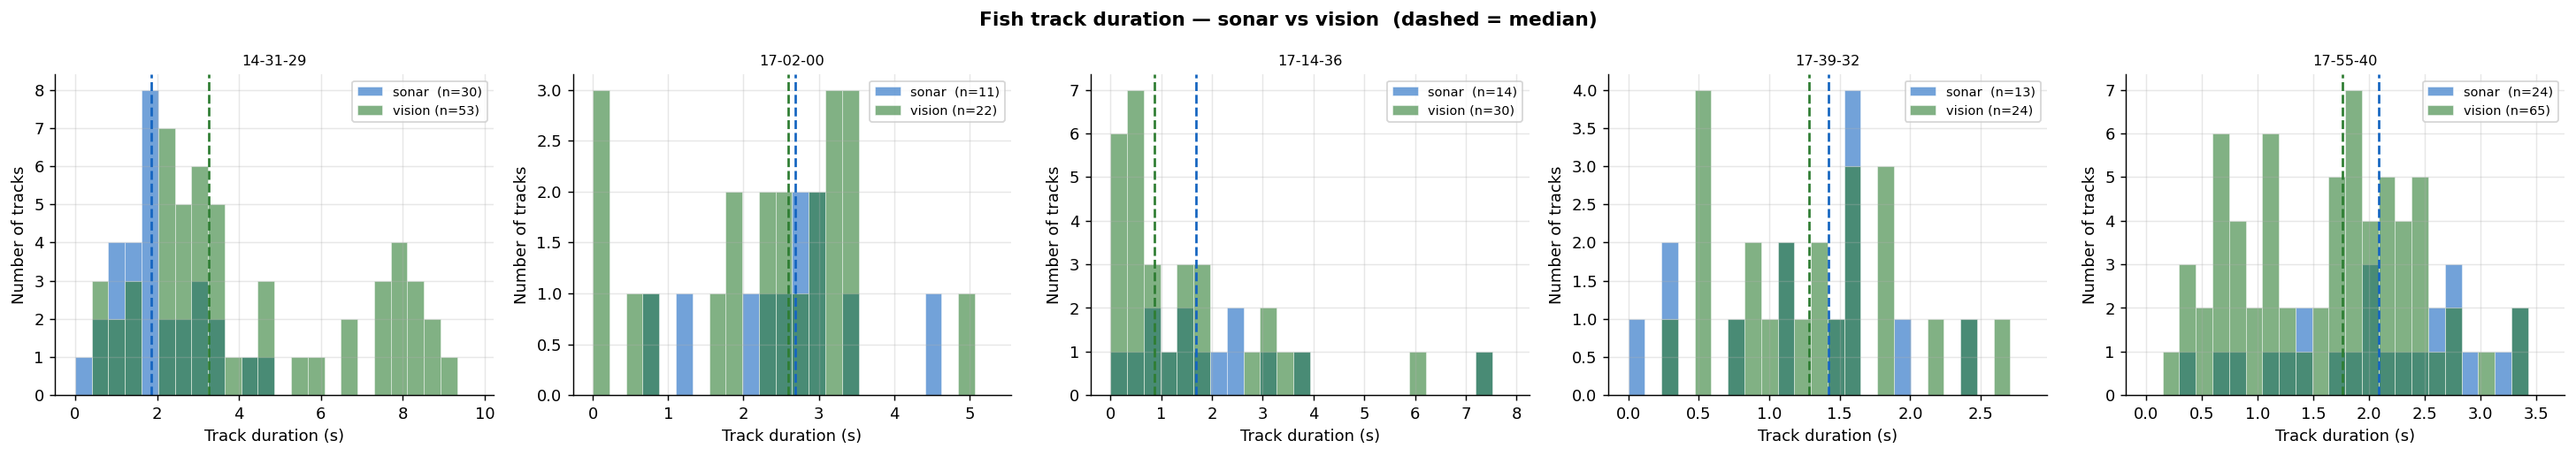

In [13]:
fig, axes = plt.subplots(1, len(SEQUENCES), figsize=(4.5*len(SEQUENCES), 4), sharey=False)

for ax, (seq, d) in zip(axes, seqdata.items()):
    fps_s = len(d["s"]["ts"]) / d["dur"]
    fps_v = len(d["v"]["ts"]) / d["dur"]

    s_len = (d["s"]["df"][d["s"]["df"]["class_id"]==1]
             .groupby("track_id")["frame_norm"].nunique() / fps_s)  # convert to seconds
    v_len = (d["v"]["df"][d["v"]["df"]["class_id"]==1]
             .groupby("track_id")["frame_norm"].nunique() / fps_v)

    bins = np.linspace(0, max(s_len.max(), v_len.max()) * 1.05, 25)
    ax.hist(s_len, bins=bins, alpha=0.6, color=C_SONAR,  label=f"sonar  (n={len(s_len)})",
            edgecolor="white", linewidth=0.4)
    ax.hist(v_len, bins=bins, alpha=0.6, color=C_VISION, label=f"vision (n={len(v_len)})",
            edgecolor="white", linewidth=0.4)

    for vals, col in [(s_len, C_SONAR), (v_len, C_VISION)]:
        ax.axvline(vals.median(), color=col, lw=1.5, ls="--")

    ax.set_xlabel("Track duration (s)")
    ax.set_ylabel("Number of tracks")
    ax.set_title(seq[-8:], fontsize=9)
    ax.legend(fontsize=8)

fig.suptitle("Fish track duration — sonar vs vision  (dashed = median)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
# plt.savefig("track_durations.png", dpi=150, bbox_inches="tight")
plt.show()

Sonar crop: x=326–943  y=314–672
Moments:    ['60.7s', '65.3s', '55.1s']



/tmp/ipykernel_3591632/2770912697.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.5)


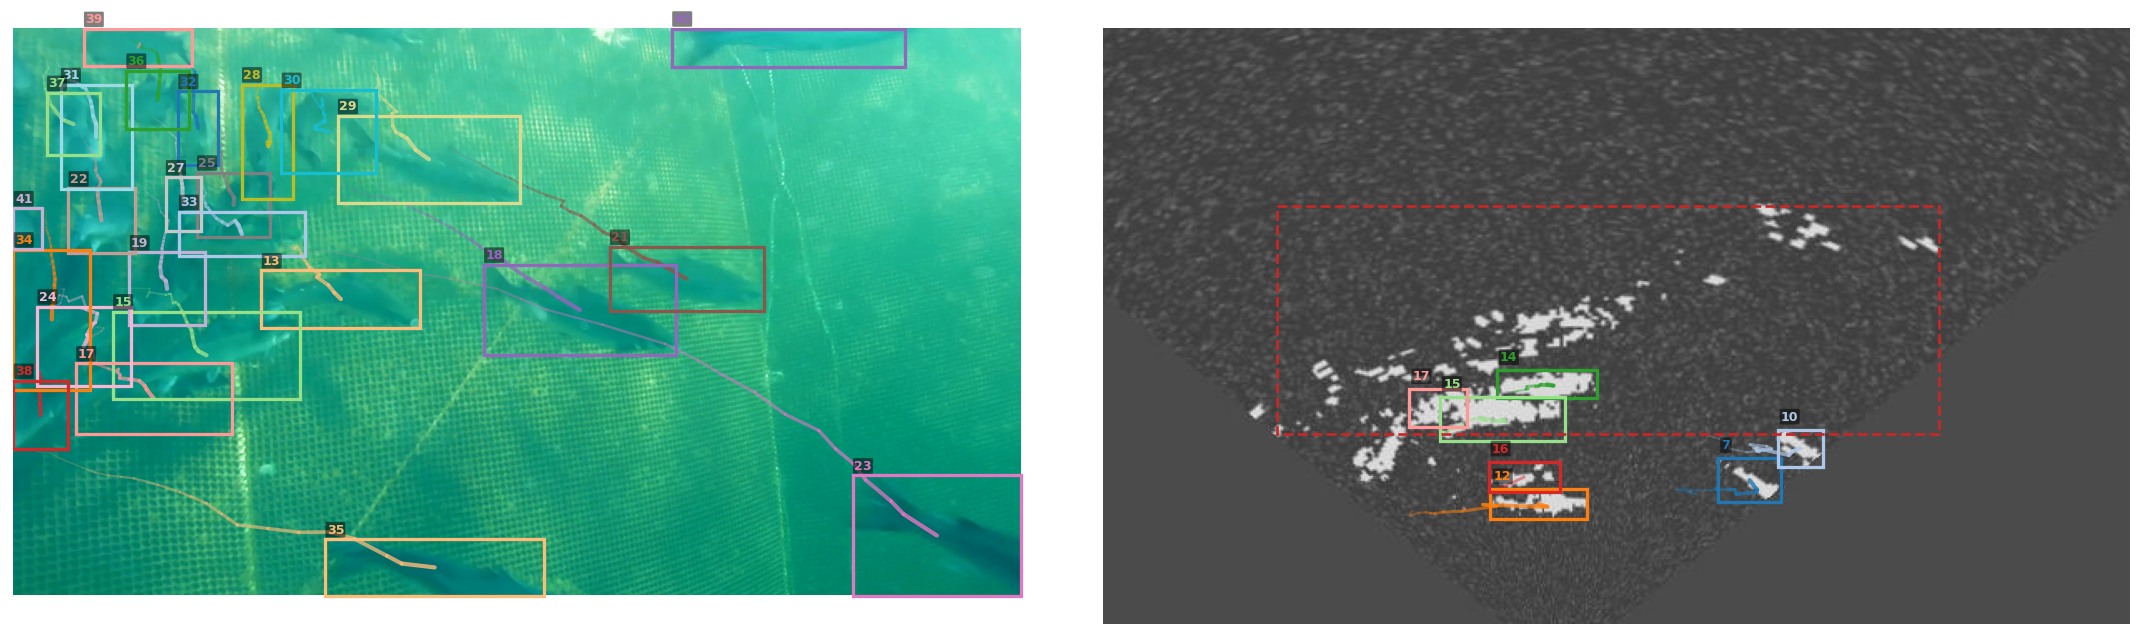

/tmp/ipykernel_3591632/2770912697.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.5)


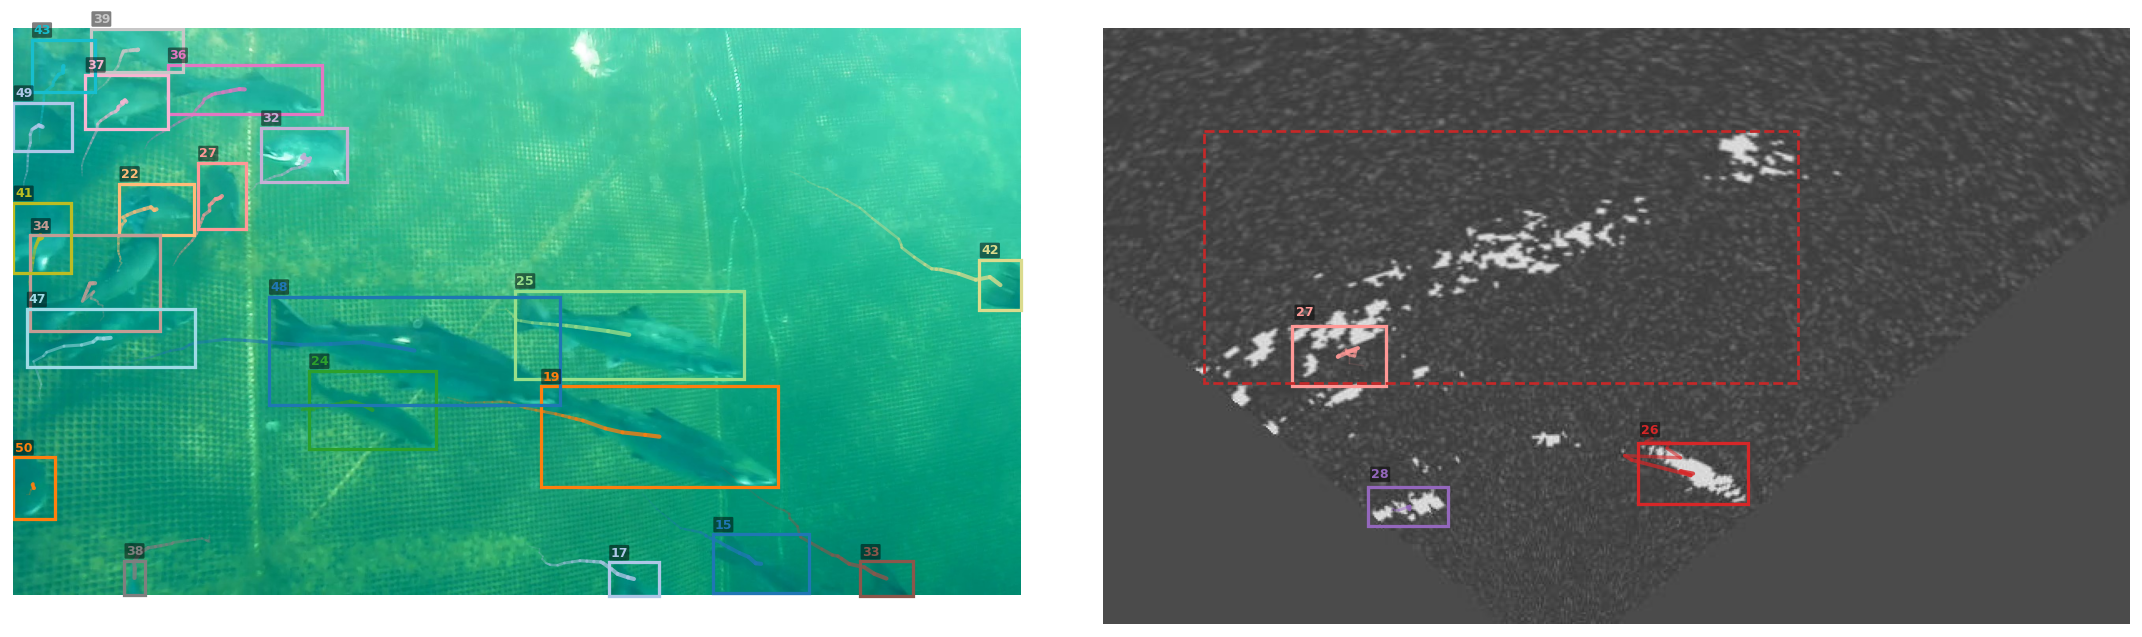

/tmp/ipykernel_3591632/2770912697.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.5)


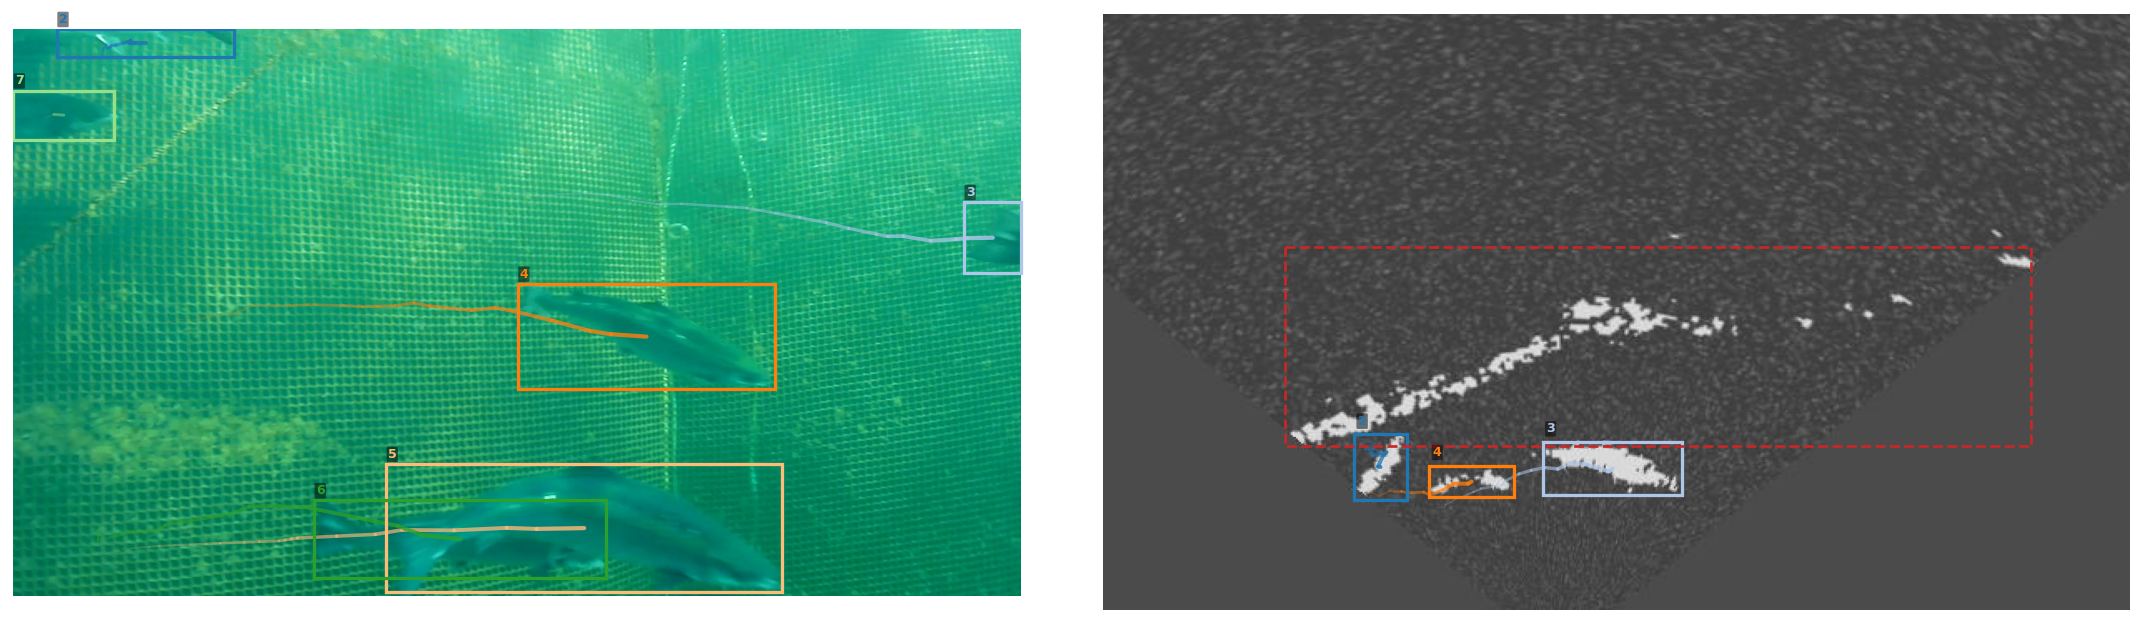

In [14]:
def find_moving_frames(seq, trail_s=1.0, n=4, min_gap_s=3.0):
    """Return n moments with highest fish movement (any fish present in both modalities)."""
    d = seqdata[seq]
    s_df, s_tl = d["s"]["df"], d["s"]["tl"]
    v_df, v_tl = d["v"]["df"], d["v"]["tl"]

    s_counts = s_df[s_df["class_id"] == 1].groupby("frame_norm").size().rename("s")
    v_counts = v_df[v_df["class_id"] == 1].groupby("frame_norm").size().rename("v")
    s_tl2 = s_tl.join(s_counts, on="frame_norm").fillna({"s": 0})
    v_tl2 = v_tl.join(v_counts, on="frame_norm").fillna({"v": 0})
    s_tl2["bin"] = (s_tl2["time_s"] / 0.1).round().astype(int)
    v_tl2["bin"] = (v_tl2["time_s"] / 0.1).round().astype(int)
    merged = (s_tl2.groupby("bin")["s"].max()
              .to_frame().join(v_tl2.groupby("bin")["v"].max(), how="inner"))
    candidates = merged[(merged["s"] >= 1) & (merged["v"] >= 1)]

    v_fish = v_df[v_df["class_id"] == 1].copy()
    v_fish["cx"] = v_fish["x"] + v_fish["w"] / 2
    v_fish["cy"] = v_fish["y"] + v_fish["h"] / 2

    scores = {}
    for bin_idx in candidates.index:
        t_now = bin_idx * 0.1
        v_idx = (v_tl["time_s"] - t_now).abs().idxmin()
        v_fn  = v_tl.loc[v_idx, "frame_norm"]
        cur_ids = set(v_fish[v_fish["frame_norm"] == v_fn]["track_id"])
        trail = v_fish[v_fish["track_id"].isin(cur_ids) &
                       (v_fish["time_s"] >= t_now - trail_s) &
                       (v_fish["time_s"] <= t_now)]
        total_disp = 0.0
        for tid, grp in trail.groupby("track_id"):
            grp = grp.sort_values("time_s")
            if len(grp) > 1:
                dx = grp["cx"].iloc[-1] - grp["cx"].iloc[0]
                dy = grp["cy"].iloc[-1] - grp["cy"].iloc[0]
                total_disp += np.sqrt(dx**2 + dy**2)
        scores[bin_idx] = total_disp

    ranked = sorted(scores, key=scores.get, reverse=True)
    chosen, seen = [], []
    for bin_idx in ranked:
        t = bin_idx * 0.1
        if all(abs(t - s) > min_gap_s for s in seen):
            chosen.append(t)
            seen.append(t)
        if len(chosen) == n:
            break
    return chosen


def sonar_crop_bounds(seq, moments, sonar_pad=60):
    """Compute a fixed crop window covering all sonar annotations across all moments."""
    d = seqdata[seq]
    s_df, s_ts, s_tl = d["s"]["df"], d["s"]["ts"], d["s"]["tl"]
    s_img_shape = plt.imread(
        str(SONAR_ROOT / seq / "frames" / f"{s_ts[0]}.jpg")
    ).shape

    all_x0, all_y0, all_x1, all_y1 = [], [], [], []
    for t in moments:
        s_idx = (s_tl["time_s"] - t).abs().idxmin()
        s_fn  = s_tl.loc[s_idx, "frame_norm"]
        anns  = s_df[s_df["frame_norm"] == s_fn]
        if anns.empty:
            continue
        all_x0.append(anns["x"].min())
        all_y0.append(anns["y"].min())
        all_x1.append((anns["x"] + anns["w"]).max())
        all_y1.append((anns["y"] + anns["h"]).max())

    x0 = int(max(0,                min(all_x0) - sonar_pad))
    y0 = int(max(0,                min(all_y0) - sonar_pad))
    x1 = int(min(s_img_shape[1],   max(all_x1) + sonar_pad))
    y1 = int(min(s_img_shape[0],   max(all_y1) + sonar_pad))
    return x0, y0, x1, y1


def show_sync_frame(seq, t_query_s, crop, trail_s=1.0, figsize_h=6, save_path=None):
    x0, y0, x1, y1 = crop
    d    = seqdata[seq]
    s_df, s_ts, s_tl = d["s"]["df"], d["s"]["ts"], d["s"]["tl"]
    v_df, v_ts, v_tl = d["v"]["df"], d["v"]["ts"], d["v"]["tl"]

    s_idx = (s_tl["time_s"] - t_query_s).abs().idxmin()
    v_idx = (v_tl["time_s"] - t_query_s).abs().idxmin()
    s_fn, v_fn = s_tl.loc[s_idx, "frame_norm"], v_tl.loc[v_idx, "frame_norm"]
    s_t,  v_t  = s_tl.loc[s_idx, "time_s"],     v_tl.loc[v_idx, "time_s"]

    s_img = plt.imread(str(SONAR_ROOT  / seq / "frames"       / f"{s_ts[int(s_fn)-1]}.jpg"))
    v_img = plt.imread(str(VISION_ROOT / seq / "frames" / seq / f"{v_ts[int(v_fn)-1]}.jpg"))

    s_cur_ids = set(s_df[(s_df["frame_norm"] == s_fn) & (s_df["class_id"] == 1)]["track_id"])
    v_cur_ids = set(v_df[(v_df["frame_norm"] == v_fn) & (v_df["class_id"] == 1)]["track_id"])

    def trail_data(df, tl, fn, t_now, cur_ids):
        fns = set(tl.loc[(tl["time_s"] >= t_now - trail_s) & (tl["frame_norm"] <= fn), "frame_norm"])
        return df[df["frame_norm"].isin(fns) & df["track_id"].isin(cur_ids) & (df["class_id"] == 1)]

    s_trail = trail_data(s_df, s_tl, s_fn, s_t, s_cur_ids)
    v_trail = trail_data(v_df, v_tl, v_fn, v_t, v_cur_ids)

    track_cmap = plt.get_cmap("tab20")
    id_color   = {tid: track_cmap(i % 20) for i, tid in enumerate(sorted(s_cur_ids | v_cur_ids))}

    def draw(ax, cur_df, trail_df, cur_fn, cur_ids):
        for tid in sorted(cur_ids):
            color = id_color[tid]
            seg = trail_df[trail_df["track_id"] == tid].sort_values("frame_norm")
            if len(seg) > 1:
                cx = (seg["x"] + seg["w"] / 2).values
                cy = (seg["y"] + seg["h"] / 2).values
                n  = len(cx)
                for i in range(n - 1):
                    ax.plot([cx[i], cx[i+1]], [cy[i], cy[i+1]],
                            color=color,
                            lw=0.8 + 1.6 * (i / (n - 1)),
                            alpha=0.12 + 0.73 * (i / (n - 1)),
                            solid_capstyle="round")
            row = cur_df[(cur_df["frame_norm"] == cur_fn) & (cur_df["track_id"] == tid)]
            if row.empty:
                continue
            r = row.iloc[0]
            ax.add_patch(plt.Rectangle((r["x"], r["y"]), r["w"], r["h"],
                                       lw=1.8, edgecolor=color, facecolor="none", zorder=5))
            ax.text(r["x"] + 2, r["y"] - 4, f"{int(tid)}",
                    color=color, fontsize=7, fontweight="bold", va="bottom", zorder=6,
                    bbox=dict(boxstyle="round,pad=0.1", fc="black", alpha=0.5, lw=0))

    s_crop = s_img[y0:y1, x0:x1]
    v_aspect = v_img.shape[1] / v_img.shape[0]
    s_aspect = s_crop.shape[1] / s_crop.shape[0]
    fig, (ax_v, ax_s) = plt.subplots(
        1, 2,
        figsize=(figsize_h * (v_aspect + s_aspect), figsize_h),
        gridspec_kw={"width_ratios": [v_aspect, s_aspect], "wspace": 0.03},
    )

    ax_v.imshow(v_img, cmap="gray" if v_img.ndim == 2 else None)
    draw(ax_v, v_df[v_df["class_id"] == 1], v_trail, v_fn, v_cur_ids)
    ax_v.set_xticks([]); ax_v.set_yticks([])
    for spine in ax_v.spines.values():
        spine.set_visible(False)

    s_cur_df = s_df[s_df["class_id"] == 1].copy()
    s_cur_df = s_cur_df.assign(x=s_cur_df["x"] - x0, y=s_cur_df["y"] - y0)
    s_trail_shifted = s_trail.copy()
    s_trail_shifted = s_trail_shifted.assign(x=s_trail_shifted["x"] - x0,
                                              y=s_trail_shifted["y"] - y0)
    ax_s.imshow(s_crop, cmap="gray" if s_crop.ndim == 2 else None)
    draw(ax_s, s_cur_df, s_trail_shifted, s_fn, s_cur_ids)
    for _, r in s_df[(s_df["frame_norm"] == s_fn) & (s_df["class_id"] == 2)].iterrows():
        ax_s.add_patch(plt.Rectangle((r["x"] - x0, r["y"] - y0), r["w"], r["h"],
                                     lw=1.5, edgecolor=C_NET, facecolor="none",
                                     linestyle="--", zorder=5))
    ax_s.set_xticks([]); ax_s.set_yticks([])
    for spine in ax_s.spines.values():
        spine.set_visible(False)

    plt.tight_layout(pad=0.5)
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()


SEQ     = SEQUENCES[0]
moments = find_moving_frames(SEQ, trail_s=1.0, n=4, min_gap_s=3.0)
crop    = sonar_crop_bounds(SEQ, moments, sonar_pad=60)
print(f"Sonar crop: x={crop[0]}–{crop[2]}  y={crop[1]}–{crop[3]}")
print(f"Moments:    {[f'{t:.1f}s' for t in moments]}\n")
for i, T in enumerate(moments):
    show_sync_frame(SEQ, T, crop=crop, trail_s=1.0,
                    save_path=f"sync_frame_nth{i}.pdf")


In [17]:
# Overlap check: which images in solaqua_fish / net_fish_sonar_improved share a
# timestamp with frames in MOT/2024-08-20_14-31-29?
#
# Each modality is compared against its own MOT directory:
#   solaqua_fish         -> vision/MOT/<seq>/frames/<seq>/   (<hash>-bagX_<timestamp>.jpg)
#   net_fish_sonar_impr. -> sonar/MOT/<seq>/frames/          (bagX_<timestamp>.jpg)

from pathlib import Path
import pandas as pd

DATA_DIR  = Path.cwd()   # data-processing/
SONAR_DIR  = DATA_DIR / "sonar"
VISION_DIR = DATA_DIR / "vision"

SEQ        = "2024-08-20_14-31-29"
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp"}

SONAR_MOT_FRAMES  = SONAR_DIR  / "MOT" / SEQ / "frames"
VISION_MOT_FRAMES = VISION_DIR / "MOT" / SEQ / "frames" / SEQ

# ── MOT timestamps per modality ────────────────────────────────────────────────
sonar_mot_ts  = {p.stem for p in SONAR_MOT_FRAMES.iterdir()  if p.suffix.lower() in IMAGE_EXTS}
vision_mot_ts = {p.stem for p in VISION_MOT_FRAMES.iterdir() if p.suffix.lower() in IMAGE_EXTS}
print(f"Sonar  MOT {SEQ}: {len(sonar_mot_ts)} frames")
print(f"Vision MOT {SEQ}: {len(vision_mot_ts)} frames")

# ── solaqua_fish (vision) ──────────────────────────────────────────────────────
solaqua_root = VISION_DIR / "solaqua_fish" / "processed" / "split_yolo"
solaqua = {}   # timestamp -> (split, filename)
for split in ("train", "val", "test"):
    for p in (solaqua_root / "images" / split).iterdir():
        if p.suffix.lower() not in IMAGE_EXTS:
            continue
        ts = p.stem.rsplit("_", 1)[-1]   # <hash>-bagX_<timestamp>
        solaqua[ts] = (split, p.name)
print(f"\nsolaqua_fish total images          : {len(solaqua)}")

# ── net_fish_sonar_improved (sonar) ───────────────────────────────────────────
sonar_root = SONAR_DIR / "net_fish_sonar_improved" / "processed"
sonar_impr = {}   # timestamp -> (split, filename)
for split in ("train", "val", "test"):
    for p in (sonar_root / "images" / split).iterdir():
        if p.suffix.lower() not in IMAGE_EXTS:
            continue
        ts = p.stem.split("_", 1)[-1]    # bagX_<timestamp>
        sonar_impr[ts] = (split, p.name)
print(f"net_fish_sonar_improved total images: {len(sonar_impr)}")

# ── Intersect each dataset against its own MOT frames ─────────────────────────
in_solaqua = vision_mot_ts & set(solaqua)
in_sonar   = sonar_mot_ts  & set(sonar_impr)
in_both    = in_solaqua & in_sonar
in_either  = in_solaqua | in_sonar

print(f"\nFrames from MOT/{SEQ} also in:")
print(f"  solaqua_fish (vs vision MOT)           : {len(in_solaqua)}")
print(f"  net_fish_sonar_improved (vs sonar MOT) : {len(in_sonar)}")
print(f"  both datasets                          : {len(in_both)}")
print(f"  either dataset (total unique)          : {len(in_either)}")

if in_either:
    rows = []
    for ts in sorted(in_either):
        rows.append({
            "timestamp":      ts,
            "in_solaqua":     ts in in_solaqua,
            "solaqua_split":  solaqua[ts][0]    if ts in in_solaqua else None,
            "solaqua_file":   solaqua[ts][1]    if ts in in_solaqua else None,
            "in_sonar_impr":  ts in in_sonar,
            "sonar_split":    sonar_impr[ts][0] if ts in in_sonar   else None,
            "sonar_file":     sonar_impr[ts][1] if ts in in_sonar   else None,
        })
    display(pd.DataFrame(rows))
else:
    print("\nNo overlapping frames found.")


Sonar  MOT 2024-08-20_14-31-29: 1060 frames
Vision MOT 2024-08-20_14-31-29: 1500 frames

solaqua_fish total images          : 793
net_fish_sonar_improved total images: 2136

Frames from MOT/2024-08-20_14-31-29 also in:
  solaqua_fish (vs vision MOT)           : 59
  net_fish_sonar_improved (vs sonar MOT) : 200
  both datasets                          : 0
  either dataset (total unique)          : 259


,timestamp,in_solaqua,solaqua_split,solaqua_file,in_sonar_impr,sonar_split,sonar_file
0,1724157091569867200,False,None,None,True,train,bag4_1724157091569867200.jpg
1,1724157091885334800,False,None,None,True,train,bag4_1724157091885334800.jpg
2,1724157092212814600,False,None,None,True,train,bag4_1724157092212814600.jpg
3,1724157092525289100,False,None,None,True,train,bag4_1724157092525289100.jpg
4,1724157092906817800,False,None,None,True,train,bag4_1724157092906817800.jpg
...,...,...,...,...,...,...,...
254,1724157158290618300,True,train,ab86abe9-bag4_1724157158290618300.jpg,False,None,None
255,1724157158321995500,False,None,None,True,train,bag4_1724157158321995500.jpg
256,1724157158649010600,False,None,None,True,train,bag4_1724157158649010600.jpg
257,1724157158961381100,False,None,None,True,train,bag4_1724157158961381100.jpg


In [18]:
# For each frame that appears in both a detection dataset and its corresponding
# MOT sequence, compare the fish instance counts.
#
# solaqua_fish (vision)        vs  vision/MOT/2024-08-20_14-31-29  — class 1 = fish
# net_fish_sonar_improved      vs  sonar/MOT/2024-08-20_14-31-29   — class 1 = fish

from pathlib import Path
import pandas as pd

DATA_DIR   = Path.cwd()
SEQ        = "2024-08-20_14-31-29"
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp"}
MOT_COLS   = ["timestamp","track_id","x","y","w","h","conf","class_id","vis"]

# ── Load MOT fish counts — ALL frames, zero-filled for frames with no fish ─────
def load_mot_fish_counts(gt_path, frames_dir):
    """Return dict {timestamp_str: fish_count} for every frame in frames_dir."""
    # All frame timestamps (ground truth for membership)
    all_ts = {p.stem for p in frames_dir.iterdir() if p.suffix.lower() in IMAGE_EXTS}
    # Fish annotations from gt.txt
    df = pd.read_csv(gt_path, header=None, names=MOT_COLS)
    df["timestamp"] = df["timestamp"].astype(str)
    fish_counts = df[df["class_id"] == 1].groupby("timestamp").size().to_dict()
    # Zero-fill frames that exist but have no fish
    return {ts: fish_counts.get(ts, 0) for ts in all_ts}

sonar_mot_fish = load_mot_fish_counts(
    DATA_DIR / "sonar/MOT"  / SEQ / "gt/gt.txt",
    DATA_DIR / "sonar/MOT"  / SEQ / "frames",
)
vision_mot_fish = load_mot_fish_counts(
    DATA_DIR / "vision/MOT" / SEQ / "gt/gt.txt",
    DATA_DIR / "vision/MOT" / SEQ / "frames" / SEQ,
)
print(f"Sonar  MOT frames (all): {len(sonar_mot_fish)}")
print(f"Vision MOT frames (all): {len(vision_mot_fish)}")

# ── Load detection dataset labels ─────────────────────────────────────────────
def load_yolo_fish_counts(images_root, labels_root, stem_to_ts_fn):
    """Return dict {timestamp_str: fish_count} across all splits."""
    counts = {}
    for split in ("train", "val", "test"):
        for p in (images_root / split).iterdir():
            if p.suffix.lower() not in IMAGE_EXTS:
                continue
            ts  = stem_to_ts_fn(p.stem)
            lbl = (labels_root / split / p.stem).with_suffix(".txt")
            fish = sum(
                1 for ln in lbl.read_text().splitlines()
                if ln.strip() and int(ln.split()[0]) == 0   # class 0 = fish in YOLO
            ) if lbl.exists() else 0
            counts[ts] = fish
    return counts

solaqua_yolo = load_yolo_fish_counts(
    DATA_DIR / "vision/solaqua_fish/processed/split_yolo/images",
    DATA_DIR / "vision/solaqua_fish/processed/split_yolo/labels",
    lambda stem: stem.rsplit("_", 1)[-1],    # <hash>-bagX_<timestamp>
)
sonar_yolo = load_yolo_fish_counts(
    DATA_DIR / "sonar/net_fish_sonar_improved/processed/images",
    DATA_DIR / "sonar/net_fish_sonar_improved/processed/labels",
    lambda stem: stem.split("_", 1)[-1],     # bagX_<timestamp>
)

# ── Build comparison tables for overlapping frames ────────────────────────────
def compare(dataset_counts, mot_counts, label):
    overlap = sorted(set(dataset_counts) & set(mot_counts))
    rows = [{"timestamp": ts,
             f"{label}_fish": dataset_counts[ts],
             "MOT_fish": mot_counts[ts],
             "diff": dataset_counts[ts] - mot_counts[ts]}
            for ts in overlap]
    return pd.DataFrame(rows)

df_vision = compare(solaqua_yolo,  vision_mot_fish, "solaqua_fish")
df_sonar  = compare(sonar_yolo,    sonar_mot_fish,  "sonar_impr")

# ── Summary ───────────────────────────────────────────────────────────────────
for label, df in [("solaqua_fish vs vision MOT", df_vision),
                  ("net_fish_sonar_improved vs sonar MOT", df_sonar)]:
    print(f"── {label} ──")
    print(f"  Overlapping frames : {len(df)}")
    if len(df):
        col_det = df.columns[1]
        print(f"  Detection dataset  — total fish: {df[col_det].sum():4d}  mean/frame: {df[col_det].mean():.2f}")
        print(f"  MOT ground truth   — total fish: {df['MOT_fish'].sum():4d}  mean/frame: {df['MOT_fish'].mean():.2f}")
        print(f"  Mean diff (det−MOT): {df['diff'].mean():+.2f}   exact match: {(df['diff']==0).sum()}/{len(df)} frames")
    print()

print("── Per-frame detail ──")
print("\nsolaqua_fish vs vision MOT:")
display(df_vision)
print("\nnet_fish_sonar_improved vs sonar MOT:")
display(df_sonar)


Sonar  MOT frames (all): 1060
Vision MOT frames (all): 1500
── solaqua_fish vs vision MOT ──
  Overlapping frames : 59
  Detection dataset  — total fish:  774  mean/frame: 13.12
  MOT ground truth   — total fish:  856  mean/frame: 14.51
  Mean diff (det−MOT): -1.39   exact match: 14/59 frames

── net_fish_sonar_improved vs sonar MOT ──
  Overlapping frames : 200
  Detection dataset  — total fish:  127  mean/frame: 0.64
  MOT ground truth   — total fish:  177  mean/frame: 0.89
  Mean diff (det−MOT): -0.25   exact match: 172/200 frames

── Per-frame detail ──

solaqua_fish vs vision MOT:


,timestamp,solaqua_fish_fish,MOT_fish,diff
0,1724157144855745800,2,2,0
1,1724157145009025000,2,2,0
2,1724157145181953200,3,3,0
3,1724157145329994500,5,5,0
4,1724157145498783300,5,5,0
5,1724157145815860300,4,5,-1
6,1724157145968368500,5,5,0
7,1724157146141586300,5,5,0
8,1724157146457031500,3,5,-2
9,1724157146774734800,4,5,-1



net_fish_sonar_improved vs sonar MOT:


,timestamp,sonar_impr_fish,MOT_fish,diff
0,1724157091569867200,0,0,0
1,1724157091885334800,0,0,0
2,1724157092212814600,0,0,0
3,1724157092525289100,0,0,0
4,1724157092906817800,0,0,0
...,...,...,...,...
195,1724157157944360900,1,1,0
196,1724157158321995500,1,1,0
197,1724157158649010600,1,1,0
198,1724157158961381100,2,2,0
